# **RAW DATASET**

In [ ]:
# ==========================================
# RAW DATASET INSPECTION
# ==========================================

import pandas as pd

# Load RAW dataset
raw_path = r"/content/Data_Set_2001_2025_Finial_Year_Project_2011_2025.xlsx"
raw_df = pd.read_excel(raw_path)

# 1️⃣ Show all column names (features)
print("RAW DATASET FEATURES:")
print(raw_df.columns.tolist())

# 2️⃣ Show number of features
print("\nTotal Features in RAW Dataset:", raw_df.shape[1])

# 3️⃣ Show first 20 columns (structure preview)
print("\nFirst 20 Columns of RAW Dataset:")
print(raw_df.iloc[:, :20].head())

# 4️⃣ Basic Info
print("\nRAW Dataset Info:")
print(raw_df.info())

RAW DATASET FEATURES:
['YEAR', 'MO', 'DY', 'HR', 'PRECTOTCORR', 'RH2M', 'QV2M', 'TQV', 'T2M', 'PS', 'SLP', 'U2M', 'V2M', 'WS2M', 'GWETROOT', 'GWETPROF', 'EVPTRNS', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN']

Total Features in RAW Dataset: 19

First 20 Columns of RAW Dataset:
   YEAR  MO  DY  HR  PRECTOTCORR    RH2M   QV2M    TQV    T2M     PS     SLP  \
0  2011   1   1   0         1.04   96.83  13.40  37.75  18.22  94.86  100.86   
1  2011   1   1   1         0.58   98.72  13.58  37.53  18.11  94.78  100.78   
2  2011   1   1   2         0.63   99.46  13.63  37.27  18.04  94.74  100.72   
3  2011   1   1   3         0.47   99.91  13.58  36.98  17.91  94.73  100.71   
4  2011   1   1   4         0.42  100.00  13.51  36.75  17.79  94.76  100.75   

    U2M   V2M  WS2M  GWETROOT  GWETPROF  EVPTRNS  ALLSKY_SFC_SW_DWN  \
0 -0.70 -0.33  0.77      0.76      0.74      0.0                0.0   
1 -0.62 -0.40  0.74      0.76      0.74      0.0                0.0   
2 -0.55 -0.46  0.72      0.76  

# **PREPROCESSED DATASET**

In [ ]:
# ==========================================
# PREPROCESSED DATASET INSPECTION
# ==========================================

import pandas as pd

# Load PREPROCESSED dataset
processed_path = r"/content/FINAL_DATASET_WITH_ROLLING.csv"
processed_df = pd.read_csv(processed_path)

# 1️⃣ Show all column names (features)
print("PREPROCESSED DATASET FEATURES:")
print(processed_df.columns.tolist())

# 2️⃣ Show number of features
print("\nTotal Features in PREPROCESSED Dataset:", processed_df.shape[1])

# 3️⃣ Show first 20 columns (structure preview)
print("\nFirst 20 Columns of PREPROCESSED Dataset:")
print(processed_df.iloc[:, :20].head())

# 4️⃣ Basic Info
print("\nPREPROCESSED Dataset Info:")
print(processed_df.info())

PREPROCESSED DATASET FEATURES:
['YEAR', 'MO', 'DY', 'HR', 'PRECTOTCORR', 'RH2M', 'QV2M', 'TQV', 'T2M', 'PS', 'SLP', 'U2M', 'V2M', 'WS2M', 'GWETROOT', 'GWETPROF', 'EVPTRNS', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN', 'DATETIME', 'MONTH', 'DAY_OF_YEAR', 'YEAR_NUM', 'rain_lag_1hr', 'rain_lag_3hr', 'rain_lag_6hr', 'rain_lag_24hr', 'MONTH_MEAN', 'MONTH_STD', 'MONTHLY_Z', 'EXPECTED_WET', 'ACTUAL_RAIN', 'RASI', 'RPI', 'rain_roll_3', 'rain_roll_6', 'rain_roll_24', 'soil_root_roll_6', 'soil_root_roll_24', 'temp_roll_6', 'temp_roll_24']

Total Features in PREPROCESSED Dataset: 41

First 20 Columns of PREPROCESSED Dataset:
   YEAR  MO  DY  HR  PRECTOTCORR    RH2M   QV2M    TQV    T2M     PS     SLP  \
0  2011   1   2  23          0.0   94.95  15.22  42.90  20.57  94.90  100.90   
1  2011   1   3   0          0.0   95.89  15.19  43.16  20.37  94.85  100.85   
2  2011   1   3   1          0.0   96.90  15.19  43.03  20.19  94.79  100.79   
3  2011   1   3   2          0.0   98.80  15.19  42.34  19.87

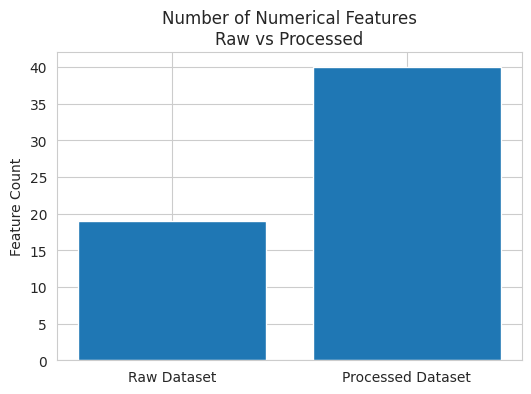

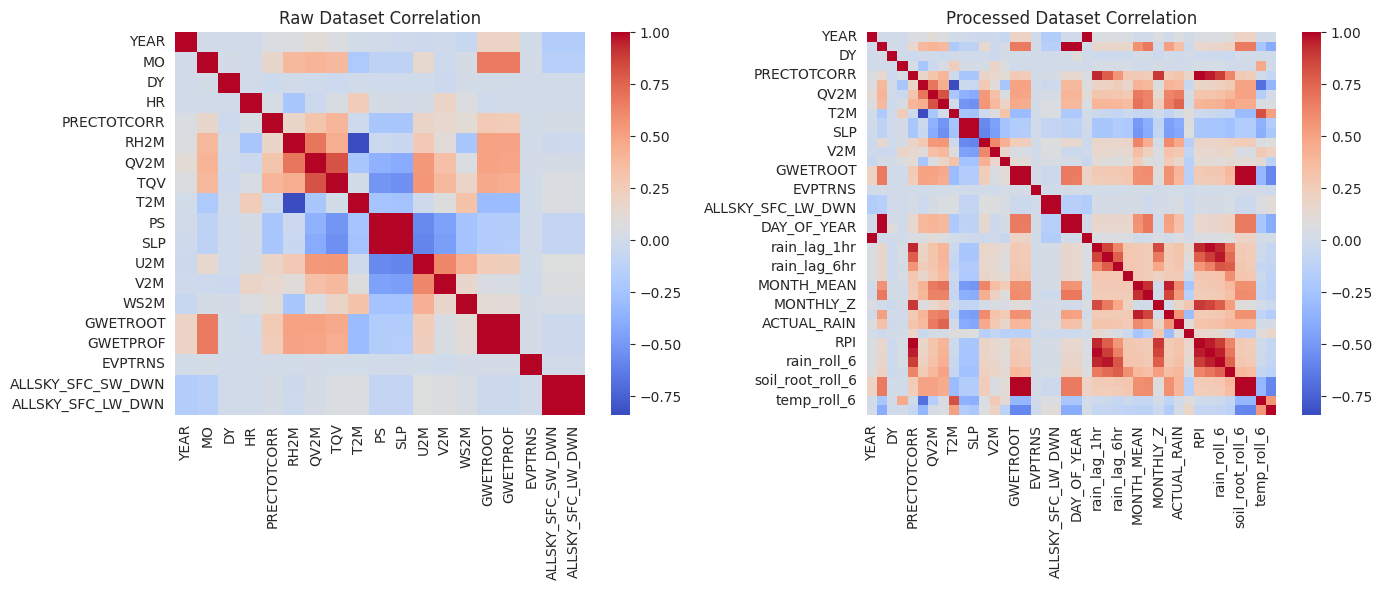

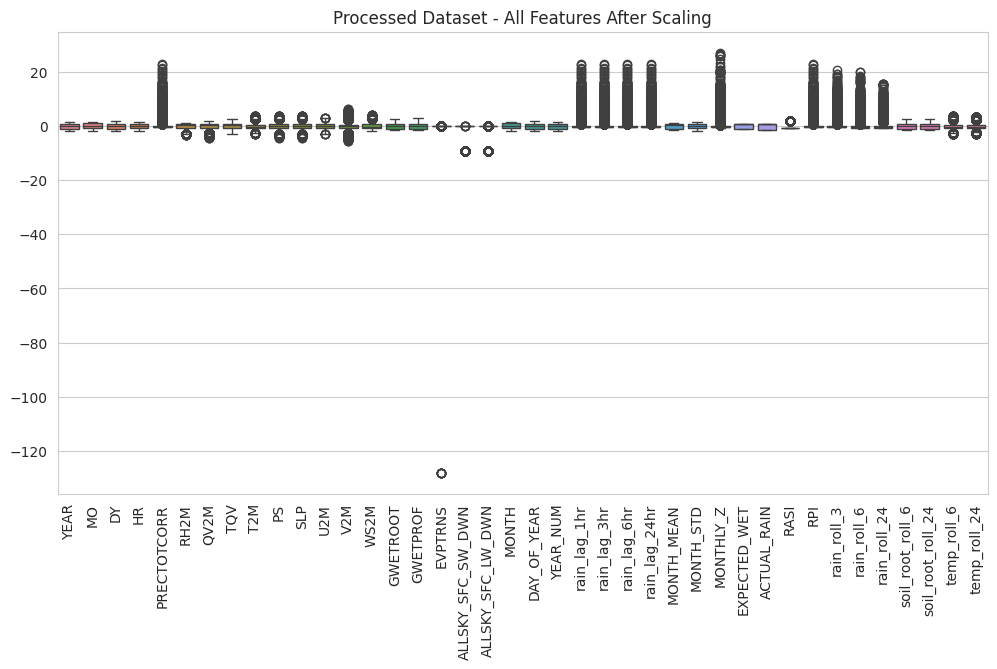

In [ ]:
# ==========================================================
# 🌧 RAW vs PROCESSED DATASET COMPARISON
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ==========================================================
# 1️⃣ LOAD RAW DATASET (Excel)
# ==========================================================

raw_df = pd.read_excel("/content/Data_Set_2001_2025_Finial_Year_Project_2011_2025 (1).xlsx")

# Convert datetime if exists
if 'DATETIME' in raw_df.columns:
    raw_df['DATETIME'] = pd.to_datetime(raw_df['DATETIME'])

# Select only numerical columns
raw_numeric = raw_df.select_dtypes(include=['int64','float64'])

# ==========================================================
# 2️⃣ LOAD PROCESSED DATASET (CSV)
# ==========================================================

processed_df = pd.read_csv("/content/FINAL_DATASET_WITH_ROLLING.csv")

if 'DATETIME' in processed_df.columns:
    processed_df['DATETIME'] = pd.to_datetime(processed_df['DATETIME'])

processed_numeric = processed_df.select_dtypes(include=['int64','float64'])

# ==========================================================
# ✅ VISUALIZATION 1: FEATURE COUNT COMPARISON
# ==========================================================

plt.figure(figsize=(6,4))

plt.bar(["Raw Dataset", "Processed Dataset"],
        [raw_numeric.shape[1], processed_numeric.shape[1]])

plt.title("Number of Numerical Features\nRaw vs Processed")
plt.ylabel("Feature Count")
plt.show()


# ==========================================================
# ✅ VISUALIZATION 2: CORRELATION MATRIX COMPARISON
# ==========================================================

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.heatmap(raw_numeric.corr(), cmap='coolwarm')
plt.title("Raw Dataset Correlation")

plt.subplot(1,2,2)
sns.heatmap(processed_numeric.corr(), cmap='coolwarm')
plt.title("Processed Dataset Correlation")

plt.tight_layout()
plt.show()


# ==========================================================
# ✅ VISUALIZATION 3: SCALING EFFECT (ALL FEATURES)
# ==========================================================

scaler = StandardScaler()
scaled_processed = scaler.fit_transform(processed_numeric)

scaled_df = pd.DataFrame(scaled_processed, columns=processed_numeric.columns)

plt.figure(figsize=(12,6))
sns.boxplot(data=scaled_df)
plt.xticks(rotation=90)
plt.title("Processed Dataset - All Features After Scaling")
plt.show()

# **FEATURE ENGINEERING DATASET**

Shape: (131449, 27)

Columns:
['YEAR', 'MO', 'DY', 'HR', 'PRECTOTCORR', 'RH2M', 'QV2M', 'TQV', 'T2M', 'PS', 'SLP', 'U2M', 'V2M', 'WS2M', 'GWETROOT', 'GWETPROF', 'EVPTRNS', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN', 'DATETIME', 'MONTH', 'DAY_OF_YEAR', 'YEAR_NUM', 'EXPECTED_WET', 'ACTUAL_RAIN', 'RASI', 'RPI']

Missing Values:
YEAR                 0
MO                   0
DY                   0
HR                   0
PRECTOTCORR          0
RH2M                 0
QV2M                 0
TQV                  0
T2M                  0
PS                   0
SLP                  0
U2M                  0
V2M                  0
WS2M                 0
GWETROOT             0
GWETPROF             0
EVPTRNS              0
ALLSKY_SFC_SW_DWN    0
ALLSKY_SFC_LW_DWN    0
DATETIME             0
MONTH                0
DAY_OF_YEAR          0
YEAR_NUM             0
EXPECTED_WET         0
ACTUAL_RAIN          0
RASI                 0
RPI                  0
dtype: int64

Statistical Summary:
                YEA

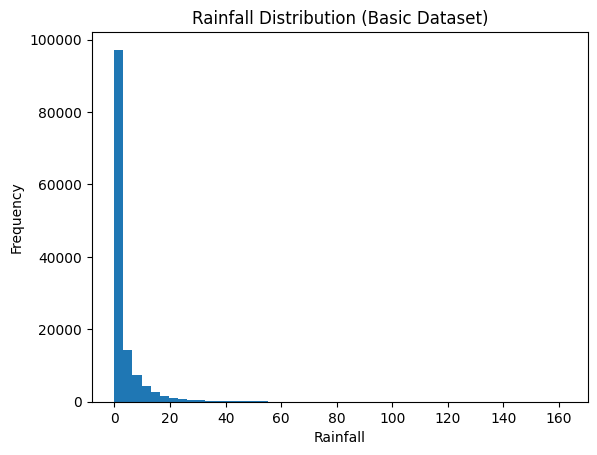

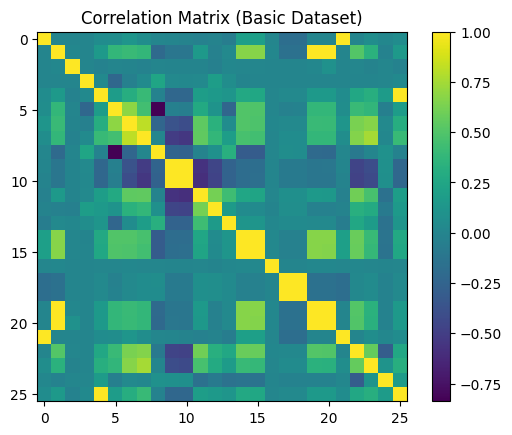

In [ ]:
# ==========================================
# EDA 1 — PREPROCESSED DATASET (BASIC FEATURES)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/FINAL_DATASET_WITH_ROLLING.csv")

# Remove engineered columns
drop_cols = [col for col in df.columns if
             "lag" in col or
             "roll" in col or
             "MONTH_MEAN" in col or
             "MONTH_STD" in col or
             "MONTHLY_Z" in col]

basic_df = df.drop(columns=drop_cols)

# ------------------------------------------
# 1. Dataset Info
# ------------------------------------------
print("Shape:", basic_df.shape)
print("\nColumns:")
print(basic_df.columns.tolist())

print("\nMissing Values:")
print(basic_df.isnull().sum())

print("\nStatistical Summary:")
print(basic_df.describe())

# ------------------------------------------
# 2. Rainfall Distribution
# ------------------------------------------
plt.figure()
plt.hist(basic_df['PRECTOTCORR'], bins=50)
plt.title("Rainfall Distribution (Basic Dataset)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------
# 3. Correlation Matrix
# ------------------------------------------
arr = basic_df.corr(numeric_only=True)

plt.figure()
plt.imshow(arr)
plt.colorbar()
plt.title("Correlation Matrix (Basic Dataset)")
plt.show()

# **EDA**

/tmp/ipython-input-704/2351476880.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


MAE: 0.0008166609667160795
RMSE: 0.026057176676271332
R2 Score: 0.9999865655578536


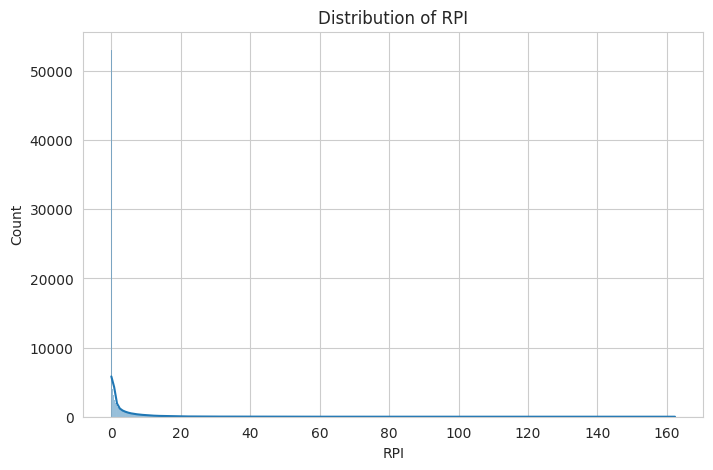

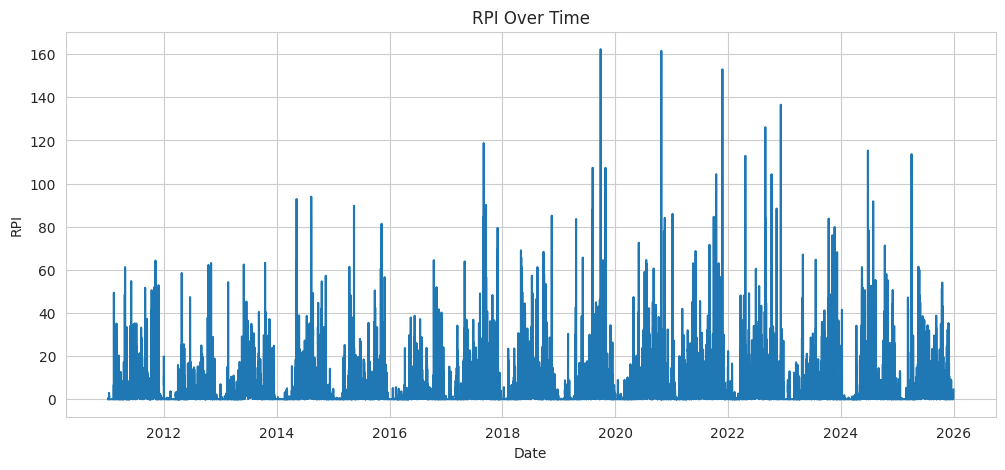

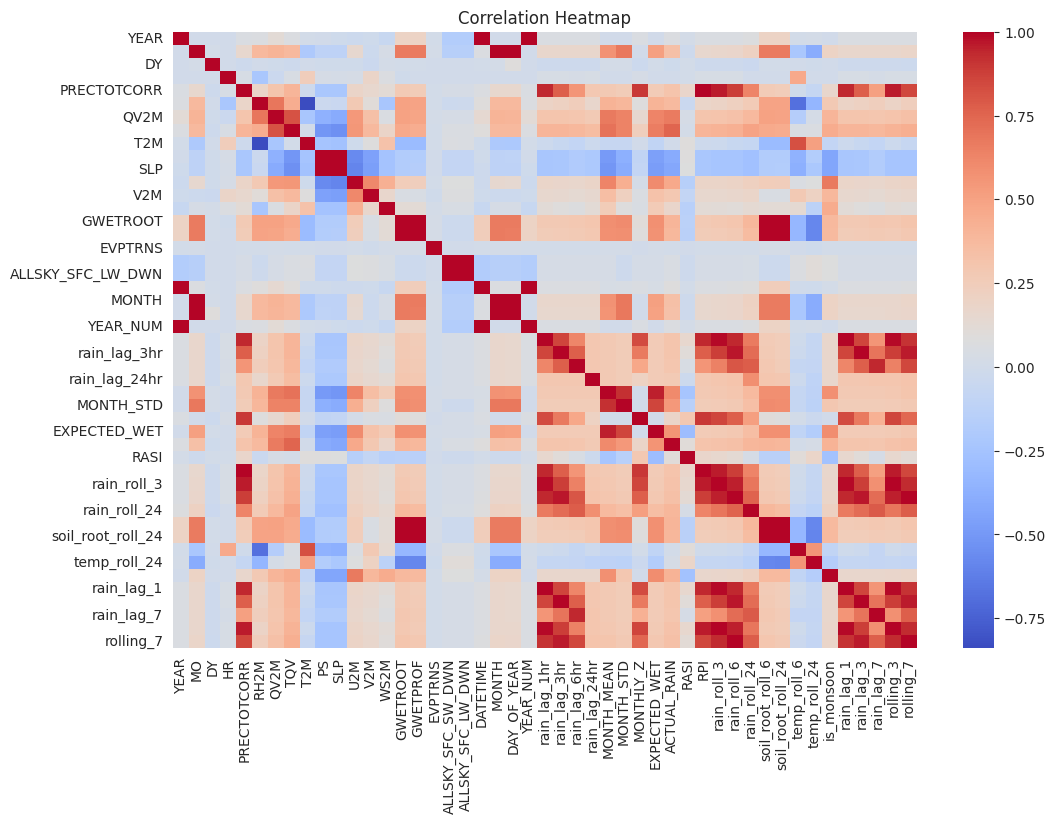

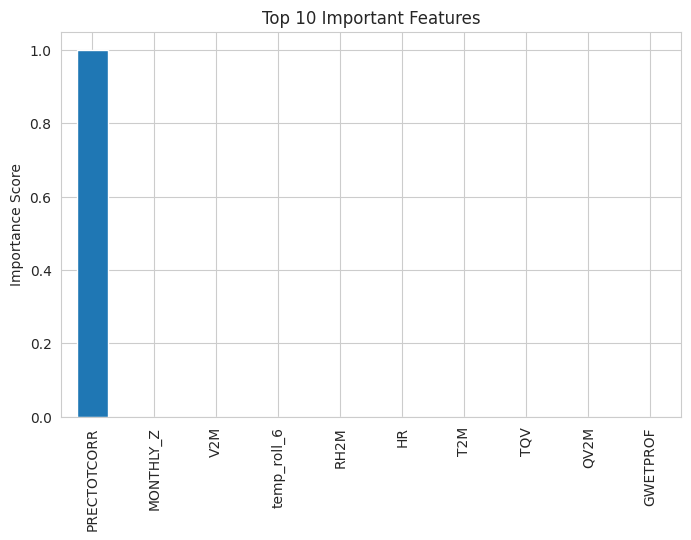

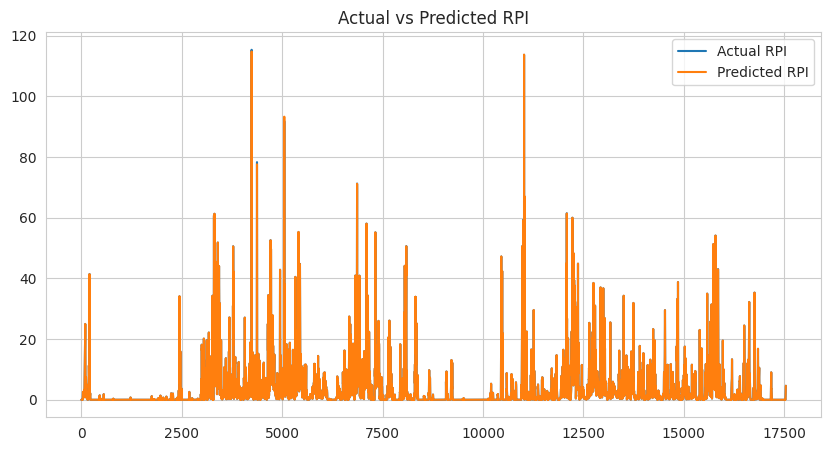

Number of Anomalies Detected: 31


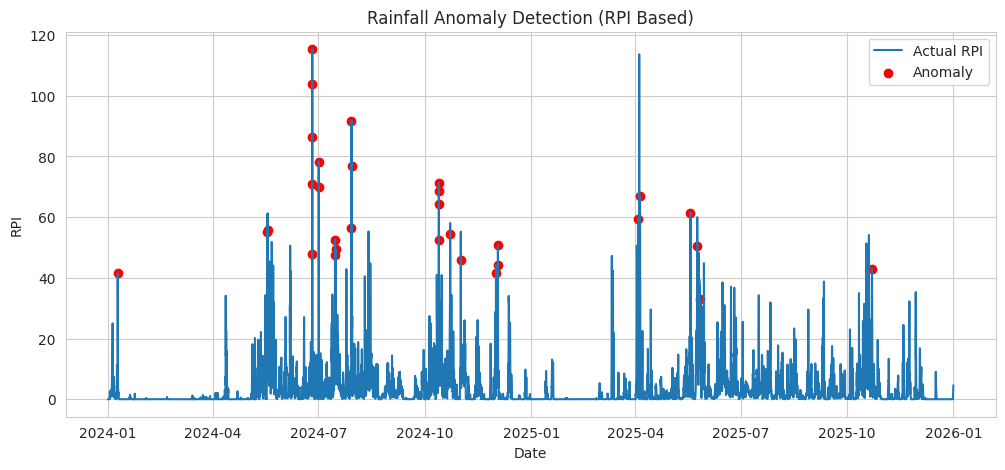

In [ ]:
# ==========================================================
# 🌧 RAINFALL ANOMALY DETECTION – COMPLETE VISUALIZATION CODE
# ==========================================================

# 1️⃣ IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

# ==========================================================
# 2️⃣ LOAD DATASET
# ==========================================================
df = pd.read_csv("/content/FINAL_DATASET_WITH_ROLLING.csv")

# Convert datetime
df['DATETIME'] = pd.to_datetime(df['DATETIME'])

# ==========================================================
# 3️⃣ DATA PREPROCESSING
# ==========================================================

# Handle missing values
df.fillna(method='ffill', inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# ==========================================================
# 4️⃣ FEATURE ENGINEERING
# ==========================================================

# Time features
df['MONTH'] = df['DATETIME'].dt.month
df['DAY_OF_YEAR'] = df['DATETIME'].dt.dayofyear

# Monsoon indicator
df['is_monsoon'] = df['MONTH'].isin([6,7,8,9]).astype(int)

# Lag features
df['rain_lag_1'] = df['PRECTOTCORR'].shift(1)
df['rain_lag_3'] = df['PRECTOTCORR'].shift(3)
df['rain_lag_7'] = df['PRECTOTCORR'].shift(7)

# Rolling features
df['rolling_3'] = df['PRECTOTCORR'].rolling(3).mean()
df['rolling_7'] = df['PRECTOTCORR'].rolling(7).mean()

# Drop NA after feature creation
df.dropna(inplace=True)

# ==========================================================
# 5️⃣ TRAIN TEST SPLIT (TIME BASED)
# ==========================================================

train = df[df['DATETIME'] < '2024-01-01']
test  = df[df['DATETIME'] >= '2024-01-01']

X_train = train.drop(['RPI','DATETIME'], axis=1)
y_train = train['RPI']

X_test = test.drop(['RPI','DATETIME'], axis=1)
y_test = test['RPI']

# ==========================================================
# 6️⃣ SCALING
# ==========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# 7️⃣ MODEL TRAINING
# ==========================================================

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# ==========================================================
# 8️⃣ MODEL EVALUATION
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ==========================================================
# 9️⃣ VISUALIZATIONS
# ==========================================================

# 1️⃣ RPI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['RPI'], kde=True)
plt.title("Distribution of RPI")
plt.show()

# 2️⃣ RPI Time Series
plt.figure(figsize=(12,5))
plt.plot(df['DATETIME'], df['RPI'])
plt.title("RPI Over Time")
plt.xlabel("Date")
plt.ylabel("RPI")
plt.show()

# 3️⃣ Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 4️⃣ Feature Importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")
plt.show()

# 5️⃣ Actual vs Predicted
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual RPI")
plt.plot(y_pred, label="Predicted RPI")
plt.legend()
plt.title("Actual vs Predicted RPI")
plt.show()

# ==========================================================
# 🔟 ANOMALY DETECTION
# ==========================================================

residuals = abs(y_test - y_pred)

threshold = residuals.mean() + 2 * residuals.std()

anomaly = residuals > threshold

print("Number of Anomalies Detected:", anomaly.sum())

# Final Anomaly Visualization
plt.figure(figsize=(12,5))

plt.plot(test['DATETIME'], y_test, label='Actual RPI')

plt.scatter(test['DATETIME'][anomaly],
            y_test[anomaly],
            color='red',
            label='Anomaly')

plt.legend()
plt.title("Rainfall Anomaly Detection (RPI Based)")
plt.xlabel("Date")
plt.ylabel("RPI")
plt.show()

# ==========================================================
# ✅ END OF COMPLETE PIPELINE
# ==========================================================

In [ ]:
# ==========================================
# EXPLORATORY DATA ANALYSIS (EDA)
# PREPROCESSED DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# 1️⃣ Load Dataset
# ------------------------------------------
df = pd.read_csv("/content/FINAL_DATASET_WITH_ROLLING.csv")

print("====================================")
print("DATASET SHAPE")
print("====================================")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# ------------------------------------------
# 2️⃣ Dataset Info
# ------------------------------------------
print("\n====================================")
print("DATASET INFO")
print("====================================")
print(df.info())


# ------------------------------------------
# 3️⃣ Missing Values
# ------------------------------------------
print("\n====================================")
print("MISSING VALUES")
print("====================================")
missing = df.isnull().sum()
print(missing[missing > 0])


# ------------------------------------------
# 4️⃣ Descriptive Statistics
# ------------------------------------------
print("\n====================================")
print("DESCRIPTIVE STATISTICS")
print("====================================")
print(df.describe())


DATASET SHAPE
Rows: 131449
Columns: 41

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131449 entries, 0 to 131448
Data columns (total 41 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   YEAR               131449 non-null  int64  
 1   MO                 131449 non-null  int64  
 2   DY                 131449 non-null  int64  
 3   HR                 131449 non-null  int64  
 4   PRECTOTCORR        131449 non-null  float64
 5   RH2M               131449 non-null  float64
 6   QV2M               131449 non-null  float64
 7   TQV                131449 non-null  float64
 8   T2M                131449 non-null  float64
 9   PS                 131449 non-null  float64
 10  SLP                131449 non-null  float64
 11  U2M                131449 non-null  float64
 12  V2M                131449 non-null  float64
 13  WS2M               131449 non-null  float64
 14  GWETROOT           131449 non-null  float64
 15

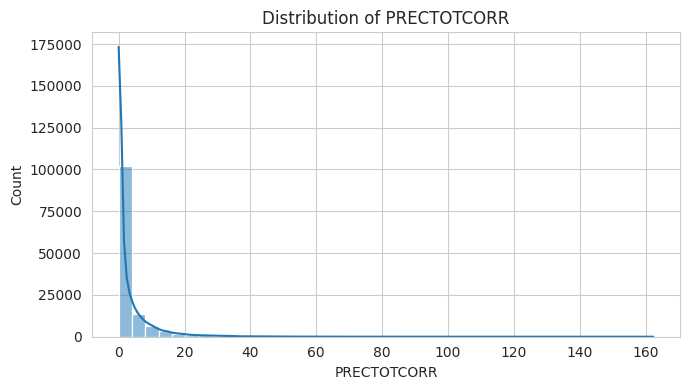

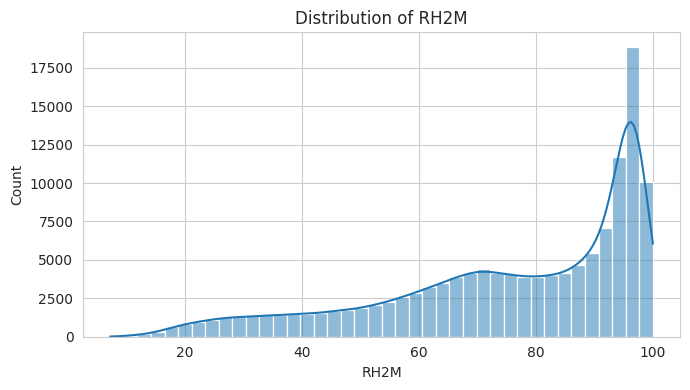

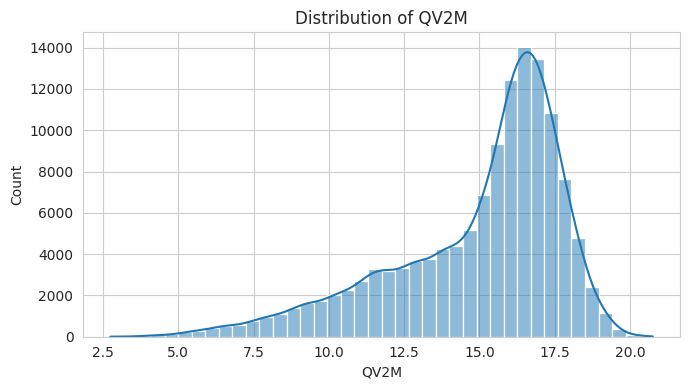

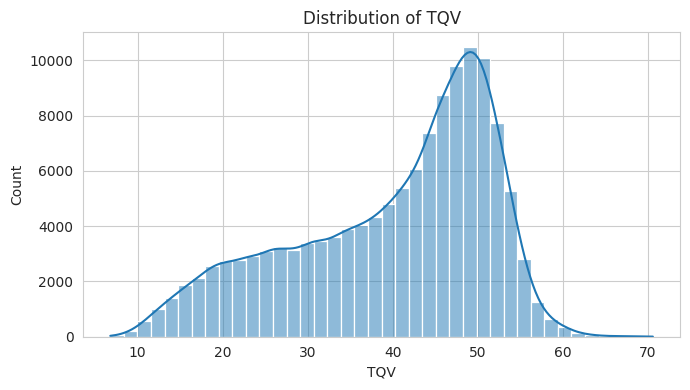

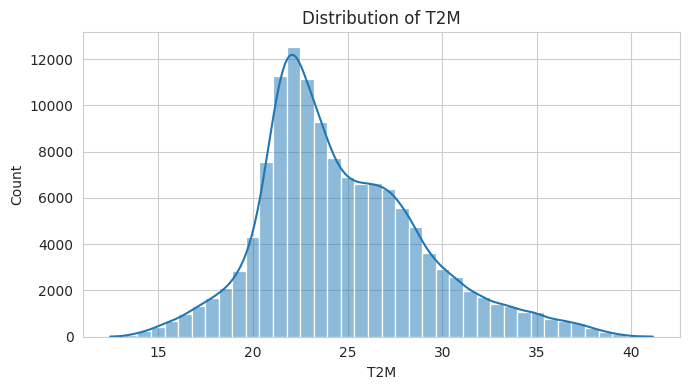

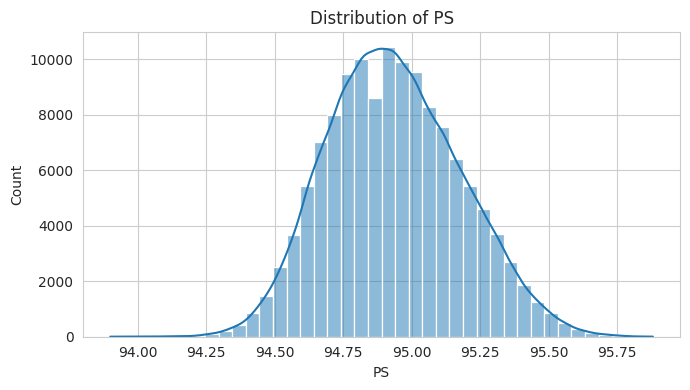

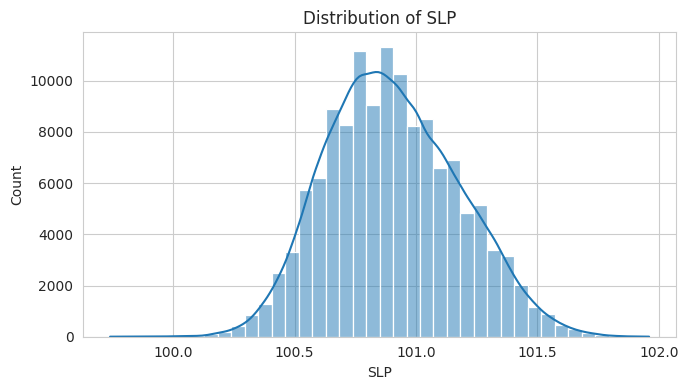

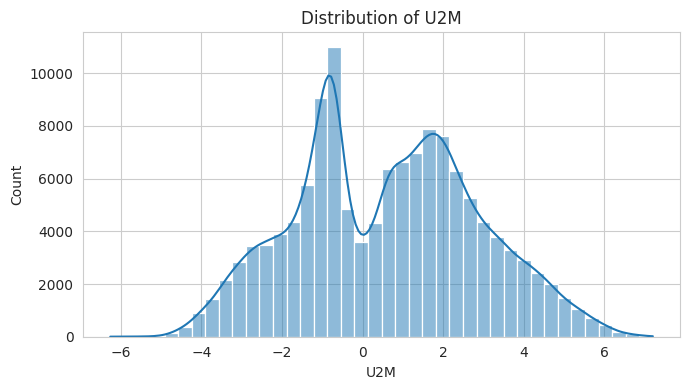

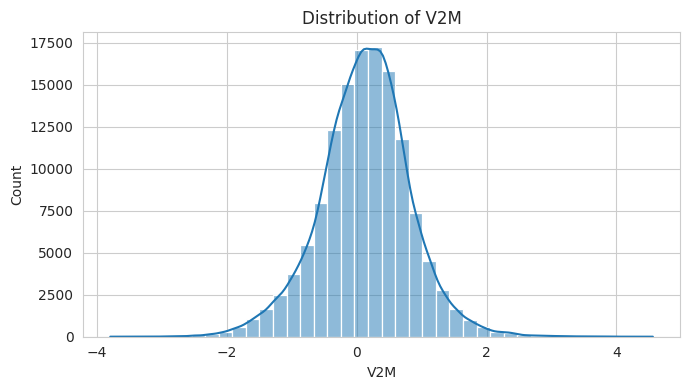

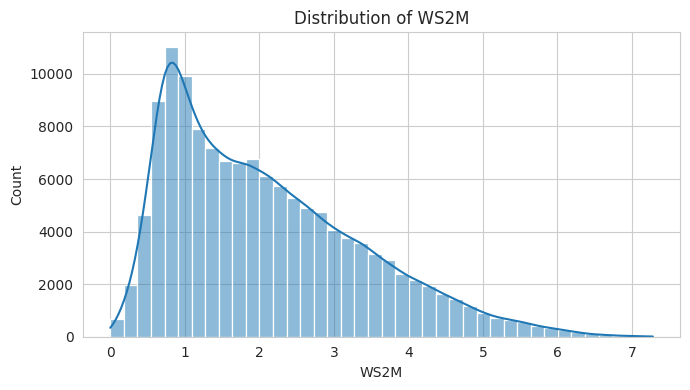

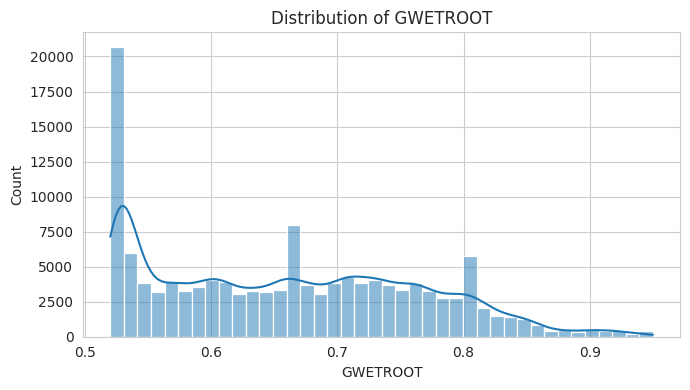

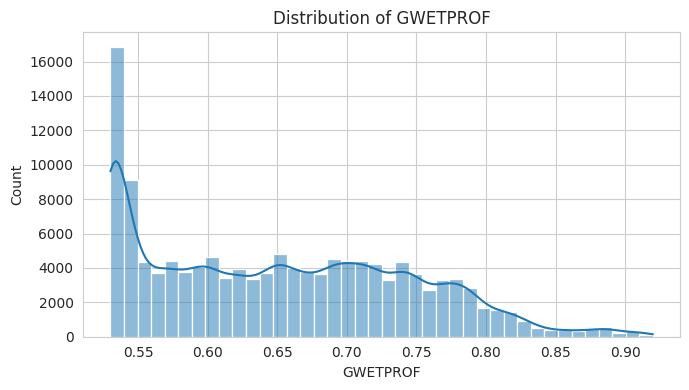

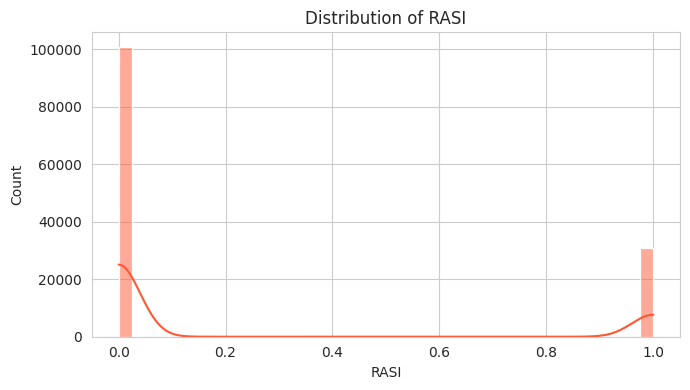

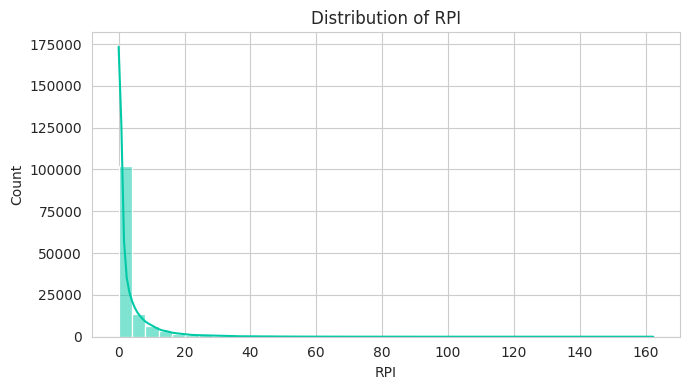

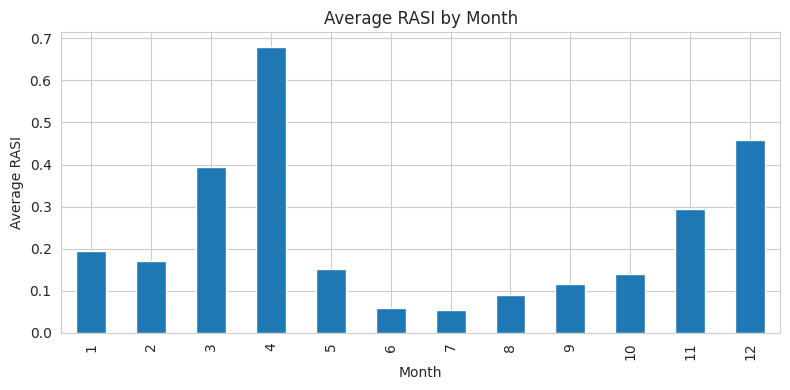

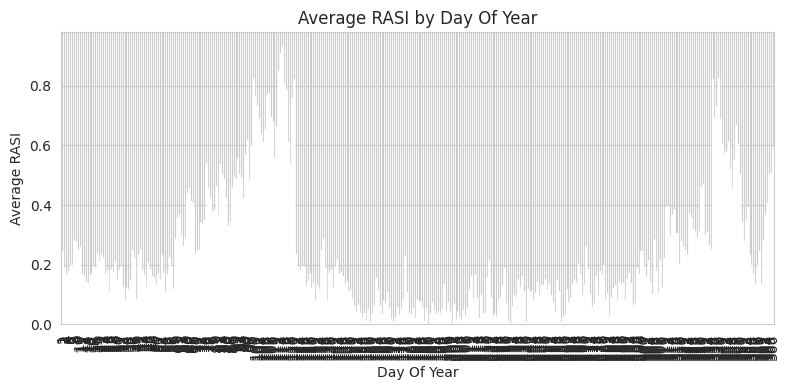

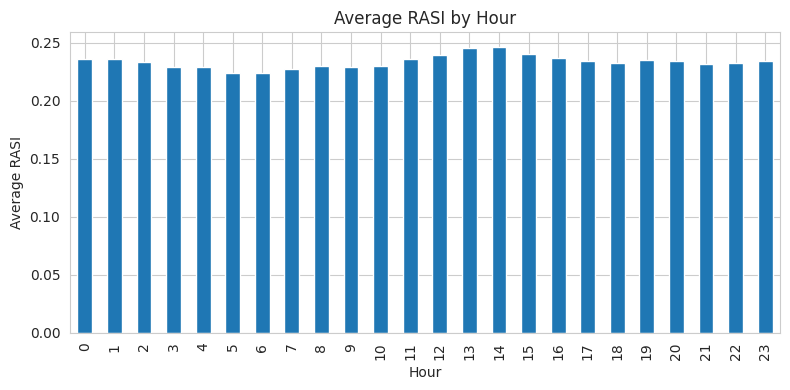

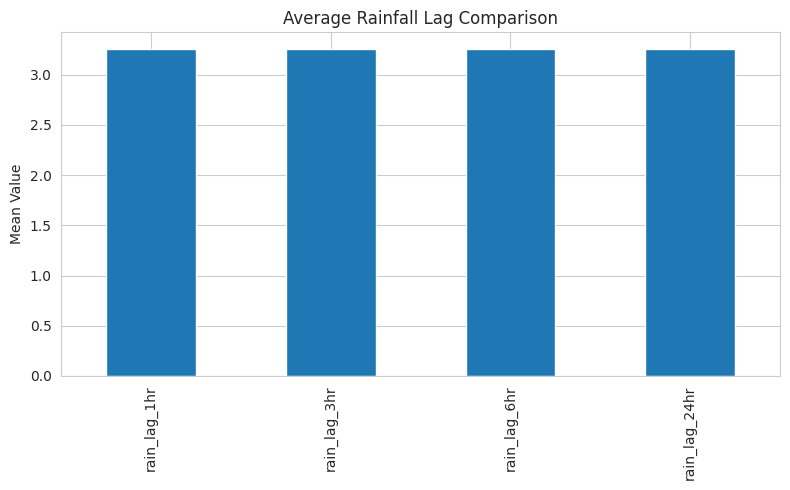

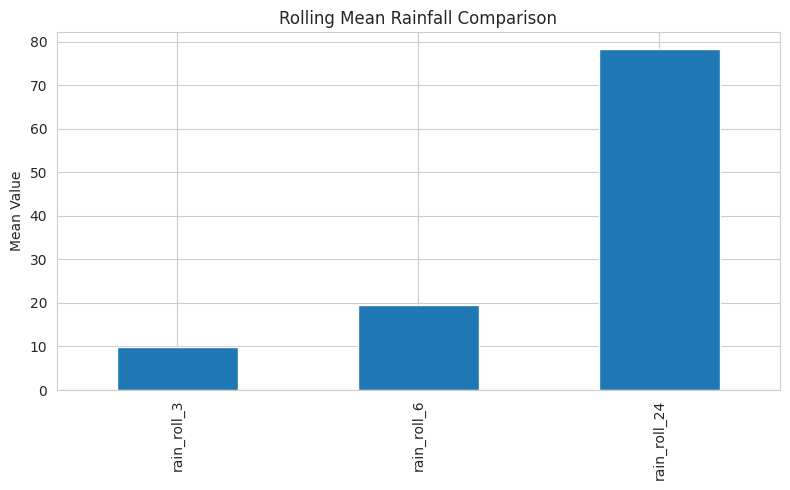

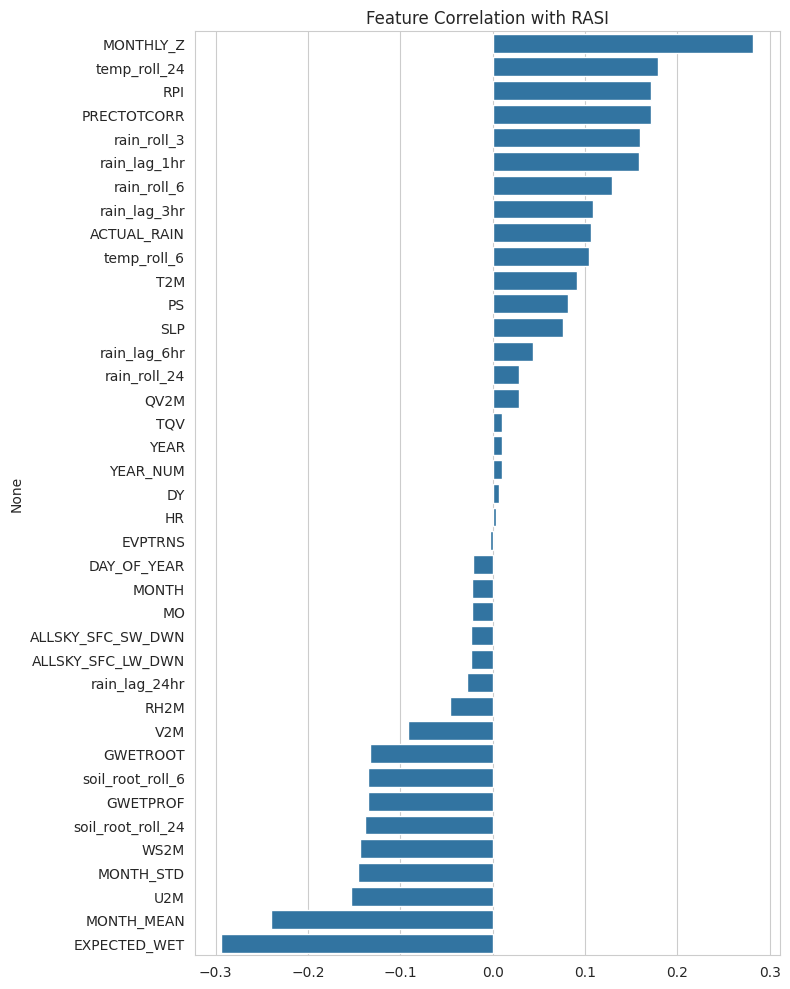

In [ ]:
# ==========================================
# 🌧 RAINFALL ANOMALY – FULL VISUALIZATION PIPELINE
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================================
# 1️⃣ LOAD DATA
# ==========================================

df = pd.read_csv("/content/FINAL_DATASET_WITH_ROLLING.csv")

DATE_COL = "DATETIME"
TARGET = "RASI"

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.sort_values(DATE_COL).reset_index(drop=True)

# ==========================================
# 2️⃣ HISTOGRAMS – METEOROLOGICAL FEATURES
# ==========================================

met_features = [
    "PRECTOTCORR","RH2M","QV2M","TQV","T2M",
    "PS","SLP","U2M","V2M","WS2M",
    "GWETROOT","GWETPROF"
]

for col in met_features:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# ==========================================
# 3️⃣ HISTOGRAMS – RAIN / ANOMALY VARIABLES (VIBRANT)
# ==========================================

vibrant_colors = ["#FF5733", "#00C9A7", "#8E44AD"]

rain_vars = ["Rain_Anomaly" if "Rain_Anomaly" in df.columns else None,
             "RASI", "RPI"]

rain_vars = [col for col in rain_vars if col is not None]

for col, color in zip(rain_vars, vibrant_colors):
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=40, kde=True, color=color)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# ==========================================
# 4️⃣ BAR PLOTS – TIME FEATURES
# ==========================================

time_features = {
    "MONTH": "Month",
    "DAY_OF_YEAR": "Day Of Year",
    "HR": "Hour"
}

for col, label in time_features.items():
    plt.figure(figsize=(8,4))
    df.groupby(col)[TARGET].mean().plot(kind="bar")
    plt.title(f"Average RASI by {label}")
    plt.xlabel(label)
    plt.ylabel("Average RASI")
    plt.tight_layout()
    plt.show()

# ==========================================
# 5️⃣ LAG FEATURES (BAR – MEAN COMPARISON)
# ==========================================

lag_cols = ["rain_lag_1hr","rain_lag_3hr","rain_lag_6hr","rain_lag_24hr"]

lag_means = df[lag_cols].mean()

plt.figure(figsize=(8,5))
lag_means.plot(kind="bar")
plt.title("Average Rainfall Lag Comparison")
plt.ylabel("Mean Value")
plt.tight_layout()
plt.show()

# ==========================================
# 6️⃣ ROLLING FEATURES (BAR – MEAN COMPARISON)
# ==========================================

roll_cols = ["rain_roll_3","rain_roll_6","rain_roll_24"]

roll_means = df[roll_cols].mean()

plt.figure(figsize=(8,5))
roll_means.plot(kind="bar")
plt.title("Rolling Mean Rainfall Comparison")
plt.ylabel("Mean Value")
plt.tight_layout()
plt.show()




# ==========================================
# 🔟 CORRELATION WITH TARGET ONLY
# ==========================================

corr = df.corr(numeric_only=True)
target_corr = corr[TARGET].drop(TARGET).sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Feature Correlation with RASI")
plt.tight_layout()
plt.show()



In [ ]:
print(df.columns)

Index(['YEAR', 'MO', 'DY', 'HR', 'PRECTOTCORR', 'RH2M', 'QV2M', 'TQV', 'T2M',
       'PS', 'SLP', 'U2M', 'V2M', 'WS2M', 'GWETROOT', 'GWETPROF', 'EVPTRNS',
       'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN', 'DATETIME', 'MONTH',
       'DAY_OF_YEAR', 'YEAR_NUM', 'rain_lag_1hr', 'rain_lag_3hr',
       'rain_lag_6hr', 'rain_lag_24hr', 'MONTH_MEAN', 'MONTH_STD', 'MONTHLY_Z',
       'EXPECTED_WET', 'ACTUAL_RAIN', 'RASI', 'RPI', 'rain_roll_3',
       'rain_roll_6', 'rain_roll_24', 'soil_root_roll_6', 'soil_root_roll_24',
       'temp_roll_6', 'temp_roll_24'],
      dtype='object')


**EXISTING MODEL**

# **Linear SVR**

In [ ]:
# ==========================================================
# MONSOON RAINFALL ANOMALY DETECTION USING OPTIMIZED LSVR
# ==========================================================

import pandas as pd
import numpy as np
import optuna
import time

from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------
df = pd.read_csv('/content/FINAL_DATASET_WITH_ROLLING.csv')

# ------------------------------------------------
# 2. Filter Monsoon Months (June–September)
# ------------------------------------------------
df = df[df['MONTH'].isin([6, 7, 8, 9])].copy()

# ------------------------------------------------
# 3. Create Lag Features
# ------------------------------------------------
lags = [1, 3, 6, 24]
for lag in lags:
    df[f'RPI_lag_{lag}'] = df['RPI'].shift(lag)

df = df.dropna().reset_index(drop=True)

# ------------------------------------------------
# 4. Feature Selection
# ------------------------------------------------
raw_features = [
    'RH2M','QV2M','TQV','T2M','PS','SLP',
    'U2M','V2M','WS2M',
    'GWETROOT','GWETPROF',
    'EVPTRNS','ALLSKY_SFC_SW_DWN','ALLSKY_SFC_LW_DWN'
]

lag_features = [f'RPI_lag_{l}' for l in lags]
X_cols = raw_features + lag_features
y_col = 'RPI'

# ------------------------------------------------
# 5. Chronological Split (NO DATA LEAKAGE)
# ------------------------------------------------
train_df = df[df['YEAR'] <= 2021]
val_df   = df[df['YEAR'] == 2022]
test_df  = df[df['YEAR'] >= 2023]

X_train, y_train = train_df[X_cols], train_df[y_col]
X_val, y_val     = val_df[X_cols], val_df[y_col]
X_test, y_test   = test_df[X_cols], test_df[y_col]

# ------------------------------------------------
# 6. Scaling
# ------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ------------------------------------------------
# 7. Optuna Hyperparameter Tuning (Validation Only)
# ------------------------------------------------
def objective(trial):
    model = LinearSVR(
        C=trial.suggest_float("C", 0.01, 100, log=True),
        epsilon=trial.suggest_float("epsilon", 0.0001, 0.5, log=True),
        tol=trial.suggest_float("tol", 1e-5, 1e-2, log=True),
        max_iter=5000,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    return mean_squared_error(y_val, preds)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)   # slightly reduced for speed

best_params = study.best_params

# ------------------------------------------------
# 8. Train Final Model (Train + Validation)
# ------------------------------------------------
X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = pd.concat([y_train, y_val])

final_model = LinearSVR(
    C=best_params["C"],
    epsilon=best_params["epsilon"],
    tol=best_params["tol"],
    max_iter=5000,
    random_state=42
)

start = time.time()
final_model.fit(X_train_full, y_train_full)
training_time = time.time() - start

# ------------------------------------------------
# 9. Evaluation Function
# ------------------------------------------------
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [mse, rmse, mae, r2]

# -------------------------
# Train Metrics
# -------------------------
train_preds = final_model.predict(X_train_full)
train_metrics = evaluate(y_train_full, train_preds)

# -------------------------
# Test Metrics
# -------------------------
test_preds = final_model.predict(X_test_scaled)
test_metrics = evaluate(y_test, test_preds)

# -------------------------
# Overall Metrics
# -------------------------
X_full = df[X_cols]
y_full = df[y_col]
X_full_scaled = scaler.transform(X_full)
overall_preds = final_model.predict(X_full_scaled)
overall_metrics = evaluate(y_full, overall_preds)

results_df = pd.DataFrame(
    [train_metrics, test_metrics, overall_metrics],
    index=["Train", "Test", "Overall"],
    columns=["MSE", "RMSE", "MAE", "R2"]
)

print("\nModel Performance Metrics (Optimized LinearSVR - Monsoon Only)\n")
print(results_df.round(4))

# ------------------------------------------------
# 10. Residual-Based Anomaly Detection (±1.5)
# ------------------------------------------------
train_residuals = y_train_full.values - train_preds
residual_std = np.std(train_residuals)

threshold = 1.5 * residual_std

test_residuals = y_test.values - test_preds

anomaly_labels = np.where(
    np.abs(test_residuals) > threshold,
    1,  # anomaly
    0   # normal
)

total_test = len(anomaly_labels)
total_anomalies = np.sum(anomaly_labels)
anomaly_percentage = (total_anomalies / total_test) * 100

print("\nResidual-Based Anomaly Detection Results\n")
print(f"Residual Threshold (±1.5σ): {round(threshold,4)}")
print(f"Total Test Observations: {total_test}")
print(f"Detected Anomalies: {total_anomalies}")
print(f"Anomaly Percentage: {round(anomaly_percentage,2)}%")
print(f"Training Time: {round(training_time,2)} seconds")

[I 2026-02-26 08:53:08,159] A new study created in memory with name: no-name-efdcb053-38c2-440c-b3d7-eee75617259d
[I 2026-02-26 08:53:09,003] Trial 0 finished with value: 5.7983253675864725 and parameters: {'C': 0.37346829829987505, 'epsilon': 0.00032145229037065445, 'tol': 5.1071051445549656e-05}. Best is trial 0 with value: 5.7983253675864725.
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
[I 2026-02-26 08:53:19,085] Trial 1 finished with value: 5.830662224921135 and parameters: {'C': 15.522207896177871, 'epsilon': 0.0009046518361413232, 'tol': 1.3045597631240394e-05}. Best is trial 0 with value: 5.7983253675864725.
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
[I 2026-02-26 08:53:30,419] Trial 2 finished with value: 5.813613878799865 and para


Model Performance Metrics (Optimized LinearSVR - Monsoon Only)

            MSE    RMSE     MAE      R2
Train    6.3593  2.5218  0.9255  0.8837
Test     4.5761  2.1392  0.9429  0.8940
Overall  6.0024  2.4500  0.9290  0.8856

Residual-Based Anomaly Detection Results

Residual Threshold (±1.5σ): 3.7821
Total Test Observations: 8784
Detected Anomalies: 388
Anomaly Percentage: 4.42%
Training Time: 12.24 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


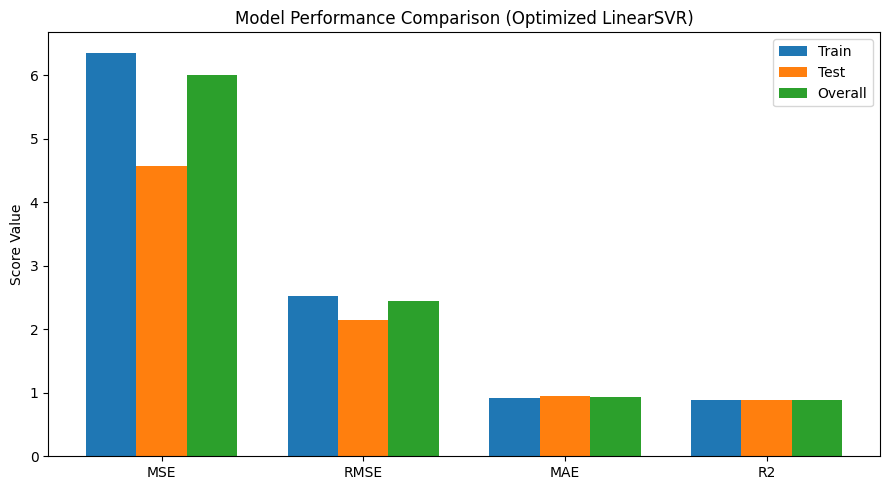

/tmp/ipython-input-4166/464372339.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_features["Feature"], rotation=45, ha="right")


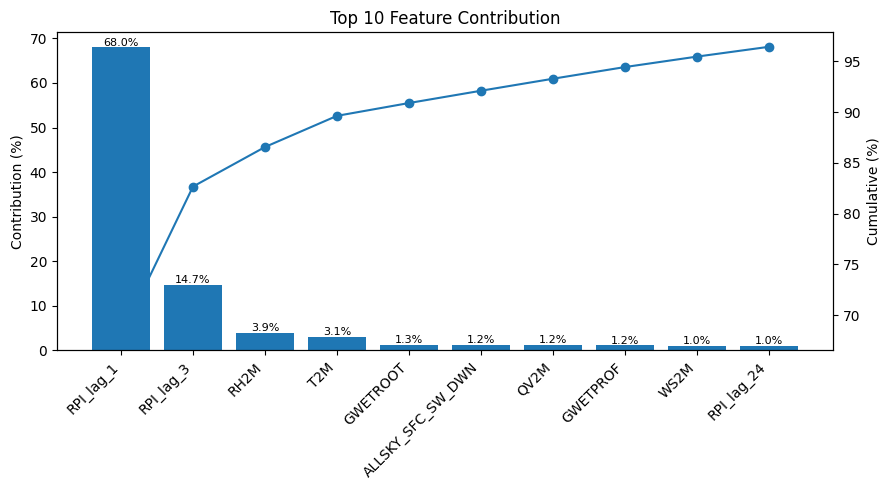

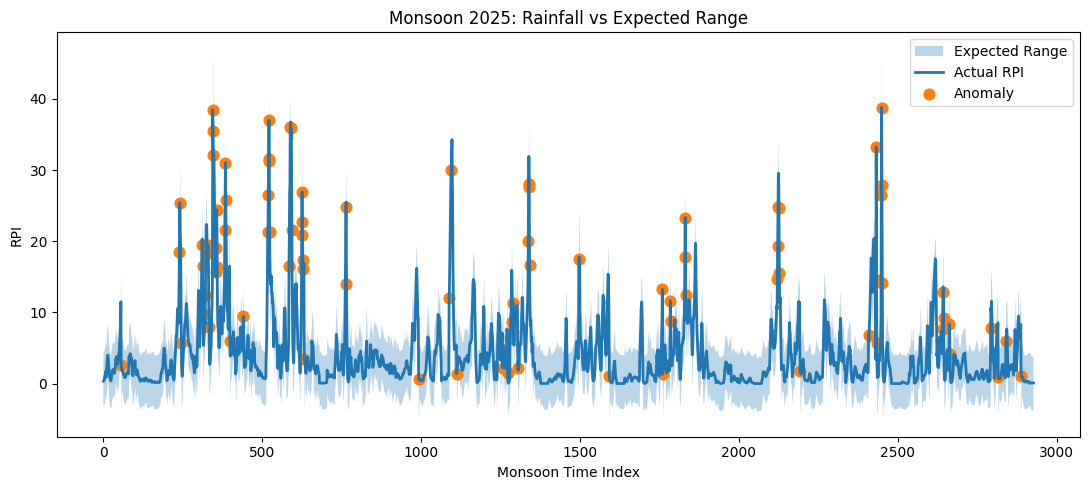

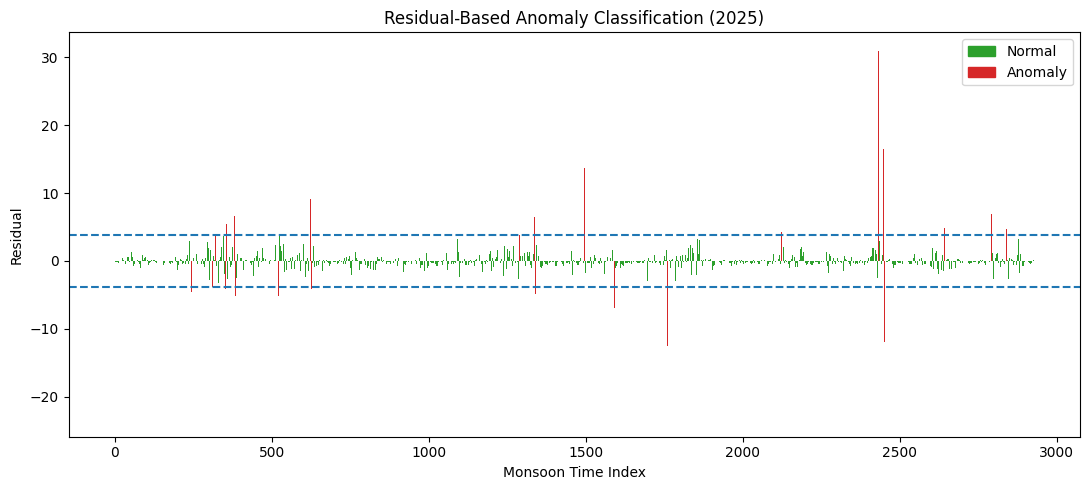

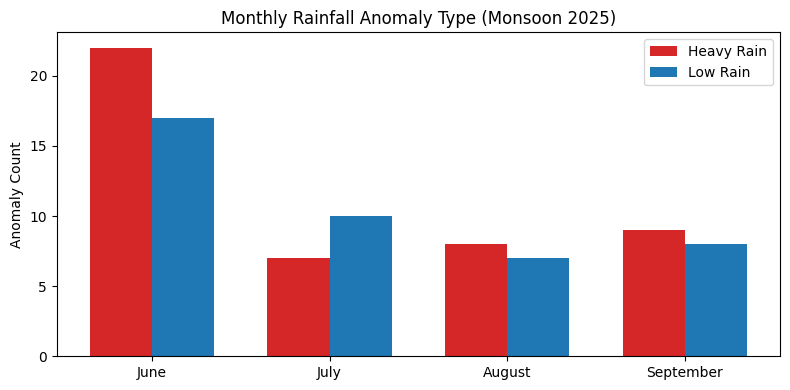

In [ ]:
# ==========================================================
# VISUALIZATION SECTION (CLEAN & ORGANIZED)
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# ==========================================================
# 1️⃣ MODEL PERFORMANCE COMPARISON
# ==========================================================

metrics = ["MSE", "RMSE", "MAE", "R2"]

train_scores = results_df.loc["Train"].values
test_scores = results_df.loc["Test"].values
overall_scores = results_df.loc["Overall"].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, train_scores, width, label="Train")
plt.bar(x, test_scores, width, label="Test")
plt.bar(x + width, overall_scores, width, label="Overall")

plt.xticks(x, metrics)
plt.ylabel("Score Value")
plt.title("Model Performance Comparison (Optimized LinearSVR)")
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================================
# 2️⃣ FEATURE CONTRIBUTION (TOP 10)
# ==========================================================

importance = np.abs(final_model.coef_)

feature_importance_df = pd.DataFrame({
    "Feature": X_cols,
    "Importance": importance
})

feature_importance_df["Contribution (%)"] = (
    feature_importance_df["Importance"] /
    feature_importance_df["Importance"].sum()
) * 100

feature_importance_df = feature_importance_df.sort_values(
    by="Contribution (%)",
    ascending=False
).reset_index(drop=True)

top_features = feature_importance_df.head(10)
cumulative = top_features["Contribution (%)"].cumsum()

fig, ax1 = plt.subplots(figsize=(9,5))

ax1.bar(top_features["Feature"], top_features["Contribution (%)"])
ax1.set_ylabel("Contribution (%)")
ax1.set_title("Top 10 Feature Contribution")
ax1.set_xticklabels(top_features["Feature"], rotation=45, ha="right")

for i, v in enumerate(top_features["Contribution (%)"]):
    ax1.text(i, v + 0.4, f"{v:.1f}%", ha='center', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(top_features["Feature"], cumulative, marker='o')
ax2.set_ylabel("Cumulative (%)")

plt.tight_layout()
plt.show()


# ==========================================================
# 3️⃣ MONSOON 2025 – RAINFALL BEHAVIOR
# ==========================================================

year_to_plot = 2025
year_df = df[df['YEAR'] == year_to_plot].copy()

X_year = scaler.transform(year_df[X_cols])
y_year = year_df['RPI'].values
y_pred_year = final_model.predict(X_year)

residuals_year = y_year - y_pred_year
anomaly_year = np.abs(residuals_year) > threshold

upper_band = y_pred_year + threshold
lower_band = y_pred_year - threshold

plt.figure(figsize=(11,5))

plt.fill_between(
    range(len(y_year)),
    lower_band,
    upper_band,
    alpha=0.3,
    label="Expected Range"
)

plt.plot(y_year, linewidth=2, label="Actual RPI")

plt.scatter(
    np.where(anomaly_year),
    y_year[anomaly_year],
    s=60,
    label="Anomaly"
)

plt.title("Monsoon 2025: Rainfall vs Expected Range")
plt.xlabel("Monsoon Time Index")
plt.ylabel("RPI")
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================================
# 4️⃣ RESIDUAL CLASSIFICATION (2025)
# ==========================================================

plt.figure(figsize=(11,5))

colors = ["#2ca02c" if not a else "#d62728" for a in anomaly_year]

plt.bar(range(len(residuals_year)), residuals_year, color=colors)

plt.axhline(threshold, linestyle='--')
plt.axhline(-threshold, linestyle='--')

normal_patch = mpatches.Patch(color="#2ca02c", label='Normal')
anomaly_patch = mpatches.Patch(color="#d62728", label='Anomaly')

plt.legend(handles=[normal_patch, anomaly_patch])

plt.title("Residual-Based Anomaly Classification (2025)")
plt.xlabel("Monsoon Time Index")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


# ==========================================================
# 5️⃣ MONTHLY POSITIVE vs NEGATIVE ANOMALY (2025)
# ==========================================================

year_df["Positive_Anomaly"] = (residuals_year > threshold).astype(int)
year_df["Negative_Anomaly"] = (residuals_year < -threshold).astype(int)

monthly_split = year_df.groupby("MONTH")[["Positive_Anomaly", "Negative_Anomaly"]].sum()

months = ["June", "July", "August", "September"]
x = np.arange(len(monthly_split))
width = 0.35

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    monthly_split["Positive_Anomaly"],
    width,
    color="#d62728",
    label="Heavy Rain"
)

plt.bar(
    x + width/2,
    monthly_split["Negative_Anomaly"],
    width,
    color="#1f77b4",
    label="Low Rain"
)

plt.xticks(x, months)
plt.ylabel("Anomaly Count")
plt.title("Monthly Rainfall Anomaly Type (Monsoon 2025)")
plt.legend()

plt.tight_layout()
plt.show()

# **DecisionTreeRegressor**

In [ ]:
# ==========================================================
# DecisionTreeRegressor + 1.5σ Adaptive Anomaly Detection
# Bayesian Hyperparameter Optimization
# ==========================================================

import pandas as pd
import numpy as np
import optuna
import time

from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------
df = pd.read_csv('/content/FINAL_DATASET_WITH_ROLLING.csv')

# ------------------------------------------------
# 2. Create Lag Features (RPI)
# ------------------------------------------------
lags = [1, 3, 6, 24]

for lag in lags:
    df[f'RPI_lag_{lag}'] = df['RPI'].shift(lag)

df = df.dropna().reset_index(drop=True)

# ------------------------------------------------
# 3. Feature Selection
# ------------------------------------------------
raw_features = [
    'RH2M','QV2M','TQV','T2M','PS','SLP',
    'U2M','V2M','WS2M',
    'GWETROOT','GWETPROF',
    'EVPTRNS','ALLSKY_SFC_SW_DWN','ALLSKY_SFC_LW_DWN'
]

lag_features = [f'RPI_lag_{l}' for l in lags]

X_cols = raw_features + lag_features
y_col = 'RPI'

# ------------------------------------------------
# 4. Chronological Split
# ------------------------------------------------
train_df = df[df['YEAR'] <= 2022]
test_df  = df[df['YEAR'] >= 2023]

X_train, y_train = train_df[X_cols], train_df[y_col]
X_test, y_test = test_df[X_cols], test_df[y_col]
X_overall, y_overall = df[X_cols], df[y_col]

# ------------------------------------------------
# 5. Normalization (fit only on train)
# ------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_overall_scaled = scaler.transform(X_overall)

# ------------------------------------------------
# 6. Bayesian Hyperparameter Tuning
# ------------------------------------------------
def objective(trial):

    model = DecisionTreeRegressor(
        max_depth=trial.suggest_int("max_depth", 3, 20),
        min_samples_split=trial.suggest_int("min_samples_split", 10, 200),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 100),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, preds)
    return mse


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25)

print("\nBest Hyperparameters:")
print(study.best_params)

# ------------------------------------------------
# 7. Train Final Model
# ------------------------------------------------
best = study.best_params

final_model = DecisionTreeRegressor(
    max_depth=best["max_depth"],
    min_samples_split=best["min_samples_split"],
    min_samples_leaf=best["min_samples_leaf"],
    max_features=best["max_features"],
    random_state=42
)

print("\nTraining Final Decision Tree...")
start = time.time()
final_model.fit(X_train_scaled, y_train)
duration = time.time() - start

# ------------------------------------------------
# 8. Evaluation
# ------------------------------------------------
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [mse, rmse, mae, r2]

train_metrics = evaluate(y_train, final_model.predict(X_train_scaled))
test_metrics = evaluate(y_test, final_model.predict(X_test_scaled))
overall_metrics = evaluate(y_overall, final_model.predict(X_overall_scaled))

results_df = pd.DataFrame(
    [train_metrics, test_metrics, overall_metrics],
    index=["Train", "Test", "Overall"],
    columns=["MSE", "RMSE", "MAE", "R2"]
)

print(f"\nTraining Duration: {duration:.2f} seconds")
print("\nDecisionTreeRegressor Results")
print(results_df)

# ==========================================================
# 9. Residual-Based 1.5σ Adaptive Anomaly Detection
# ==========================================================

# --- Predictions ---
y_pred_train = final_model.predict(X_train_scaled)
y_pred_test = final_model.predict(X_test_scaled)
y_pred_overall = final_model.predict(X_overall_scaled)

# --- Residuals ---
train_residuals = y_train - y_pred_train
test_residuals = y_test - y_pred_test
overall_residuals = y_overall - y_pred_overall

# ------------------------------------------------
# 10. Adaptive Threshold (Based on TRAIN residuals)
# ------------------------------------------------
sigma = np.std(train_residuals)
threshold = 1.5 * sigma

print("\nResidual Threshold (±1.5σ):", round(threshold, 4))

# ------------------------------------------------
# 11. Anomaly Classification (Test Set Focus)
# ------------------------------------------------
test_anomalies = np.abs(test_residuals) > threshold

# Add to test_df for clarity
test_df = test_df.copy()
test_df["Predicted_RPI"] = y_pred_test
test_df["Residual"] = test_residuals
test_df["Anomaly"] = test_anomalies.astype(int)

test_df["Positive_Anomaly"] = (test_residuals > threshold).astype(int)
test_df["Negative_Anomaly"] = (test_residuals < -threshold).astype(int)

# ------------------------------------------------
# 12. Anomaly Summary (Test Set)
# ------------------------------------------------
total_obs = len(test_df)
total_anomalies = test_df["Anomaly"].sum()
positive_anomalies = test_df["Positive_Anomaly"].sum()
negative_anomalies = test_df["Negative_Anomaly"].sum()

print("\n===== ADAPTIVE ANOMALY DETECTION SUMMARY (Test Set) =====")
print(f"Total Test Observations: {total_obs}")
print(f"Detected Anomalies: {total_anomalies}")
print(f"Anomaly Percentage: {100 * total_anomalies / total_obs:.2f}%")
print(f"Positive Anomalies (Extreme Rain): {positive_anomalies}")
print(f"Negative Anomalies (Low Rain): {negative_anomalies}")

[I 2026-02-26 10:09:59,134] A new study created in memory with name: no-name-66e9eaa4-3837-4e7f-b8af-677f937b2f64
[I 2026-02-26 10:10:01,527] Trial 0 finished with value: 6.059323389743116 and parameters: {'max_depth': 16, 'min_samples_split': 143, 'min_samples_leaf': 8, 'max_features': 0.669746767244426}. Best is trial 0 with value: 6.059323389743116.
[I 2026-02-26 10:10:02,854] Trial 1 finished with value: 9.123552114657215 and parameters: {'max_depth': 12, 'min_samples_split': 175, 'min_samples_leaf': 73, 'max_features': 0.382119109236451}. Best is trial 0 with value: 6.059323389743116.
[I 2026-02-26 10:10:05,955] Trial 2 finished with value: 6.4861747290122205 and parameters: {'max_depth': 11, 'min_samples_split': 38, 'min_samples_leaf': 89, 'max_features': 0.8318896075336712}. Best is trial 0 with value: 6.059323389743116.
[I 2026-02-26 10:10:07,495] Trial 3 finished with value: 7.490317929869097 and parameters: {'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 89, 'm


Best Hyperparameters:
{'max_depth': 9, 'min_samples_split': 28, 'min_samples_leaf': 84, 'max_features': 0.6704681772788145}

Training Final Decision Tree...

Training Duration: 1.19 seconds

DecisionTreeRegressor Results
              MSE      RMSE       MAE        R2
Train    4.893555  2.212138  0.629508  0.898909
Test     5.726919  2.393098  0.758304  0.883591
Overall  5.060348  2.249522  0.655285  0.895814

Residual Threshold (±1.5σ): 3.3182

===== ADAPTIVE ANOMALY DETECTION SUMMARY (Test Set) =====
Total Test Observations: 26304
Detected Anomalies: 1294
Anomaly Percentage: 4.92%
Positive Anomalies (Extreme Rain): 655
Negative Anomalies (Low Rain): 639


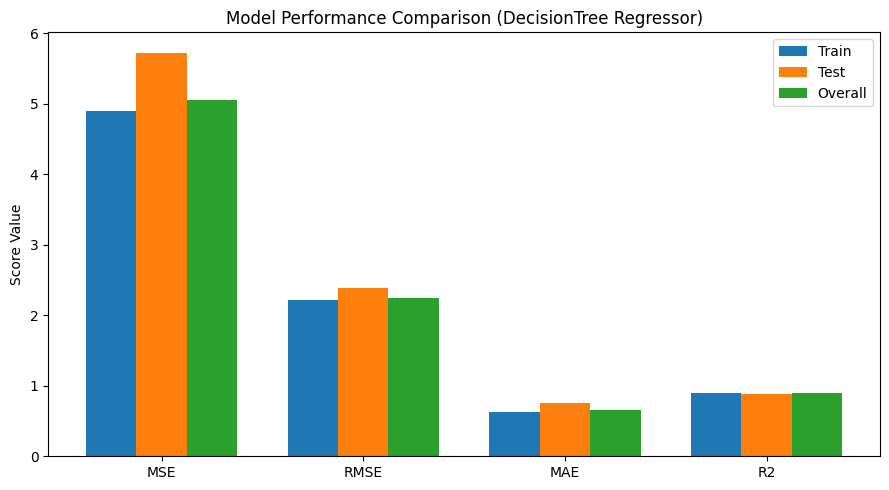

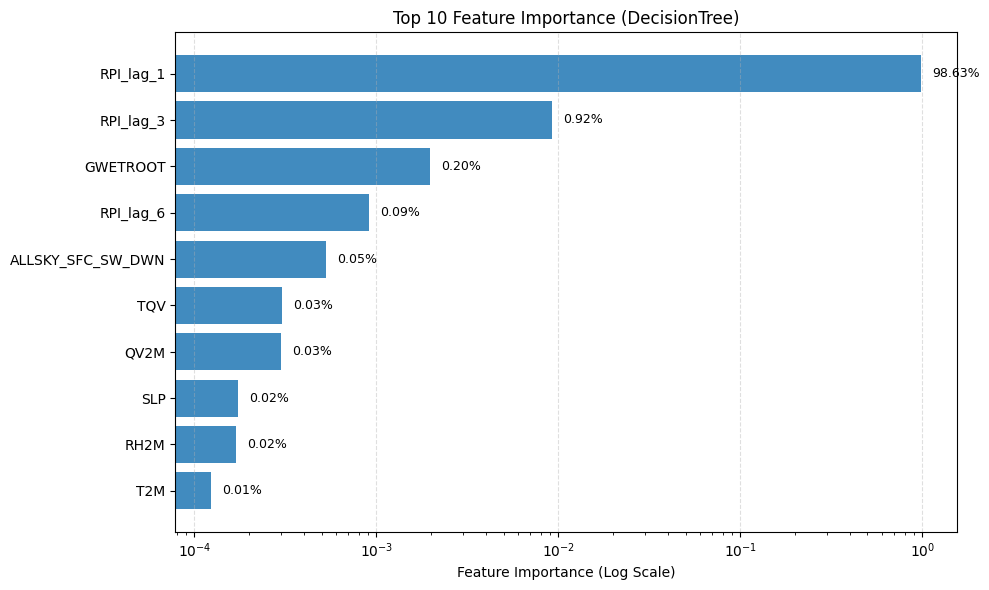

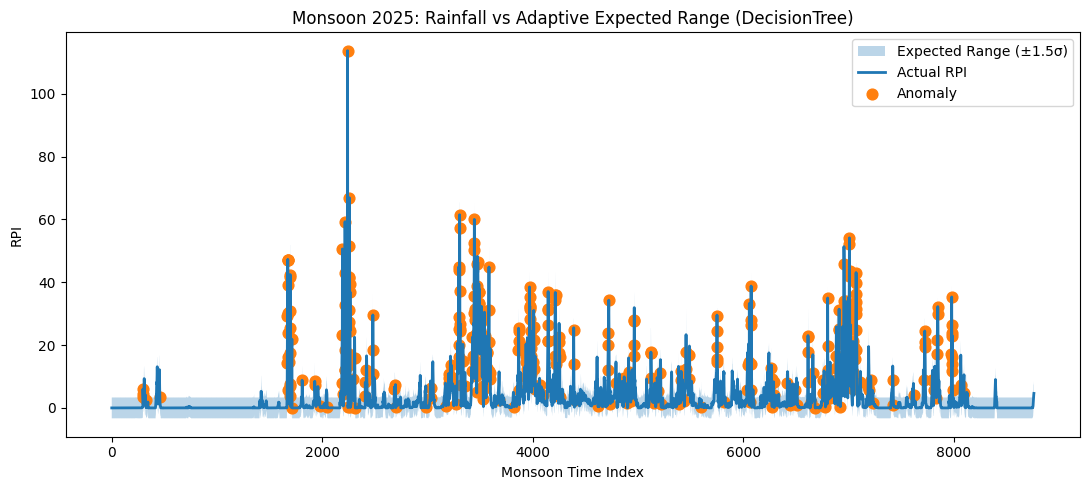

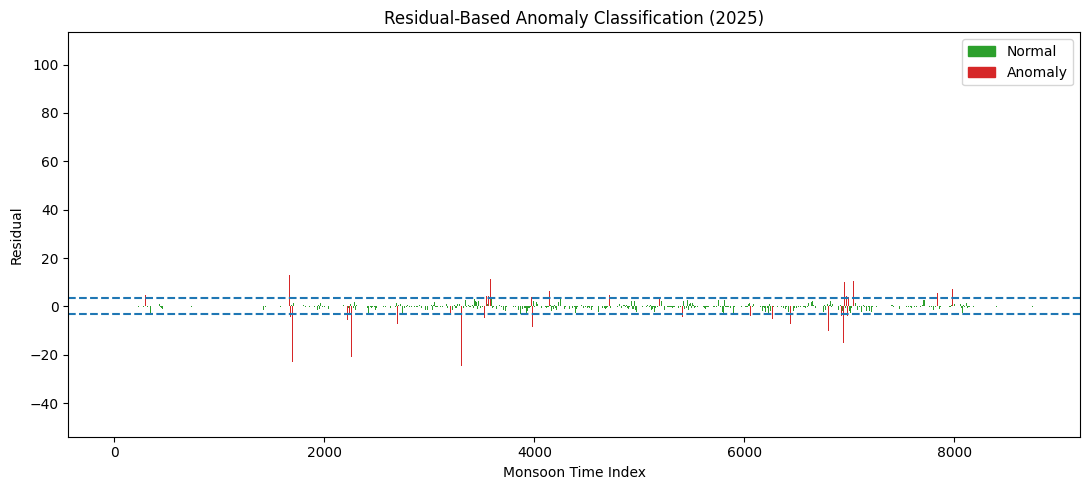

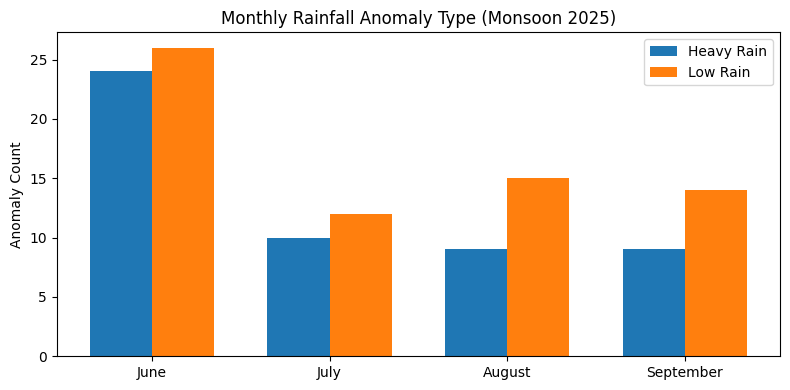

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# ==========================================================
# 1️⃣ MODEL PERFORMANCE COMPARISON
# ==========================================================

metrics = ["MSE", "RMSE", "MAE", "R2"]

train_scores = results_df.loc["Train"].values
test_scores = results_df.loc["Test"].values
overall_scores = results_df.loc["Overall"].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, train_scores, width, label="Train")
plt.bar(x, test_scores, width, label="Test")
plt.bar(x + width, overall_scores, width, label="Overall")

plt.xticks(x, metrics)
plt.ylabel("Score Value")
plt.title("Model Performance Comparison (DecisionTree Regressor)")
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================================
# 2️⃣ FEATURE IMPORTANCE (TOP 10 — LOG SCALE)
# ==========================================================

importance = final_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_cols,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

top_features = feature_importance_df.head(10).copy()

# Percentage contribution
top_features["Contribution (%)"] = (
    top_features["Importance"] /
    top_features["Importance"].sum()
) * 100

# Add epsilon to avoid log(0)
top_features["Importance"] += 1e-8

# Reverse for horizontal plotting
top_features = top_features.iloc[::-1]

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    alpha=0.85
)

plt.xscale("log")
plt.xlabel("Feature Importance (Log Scale)")
plt.title("Top 10 Feature Importance (DecisionTree)")

# Add % labels
for i, (value, percent) in enumerate(
    zip(top_features["Importance"], top_features["Contribution (%)"])
):
    plt.text(value * 1.15, i, f"{percent:.2f}%", va="center", fontsize=9)

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# ==========================================================
# 3️⃣ MONSOON 2025 – RAINFALL BEHAVIOR
# ==========================================================

year_to_plot = 2025
year_df = df[df['YEAR'] == year_to_plot].copy()

X_year = scaler.transform(year_df[X_cols])
y_year = year_df['RPI'].values
y_pred_year = final_model.predict(X_year)

residuals_year = y_year - y_pred_year
anomaly_year = np.abs(residuals_year) > threshold

upper_band = y_pred_year + threshold
lower_band = y_pred_year - threshold

plt.figure(figsize=(11,5))

plt.fill_between(
    range(len(y_year)),
    lower_band,
    upper_band,
    alpha=0.3,
    label="Expected Range (±1.5σ)"
)

plt.plot(y_year, linewidth=2, label="Actual RPI")

plt.scatter(
    np.where(anomaly_year),
    y_year[anomaly_year],
    s=60,
    label="Anomaly"
)

plt.title("Monsoon 2025: Rainfall vs Adaptive Expected Range (DecisionTree)")
plt.xlabel("Monsoon Time Index")
plt.ylabel("RPI")
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================================
# 4️⃣ RESIDUAL CLASSIFICATION (2025)
# ==========================================================

plt.figure(figsize=(11,5))

colors = ["#2ca02c" if not a else "#d62728" for a in anomaly_year]

plt.bar(range(len(residuals_year)), residuals_year, color=colors)

plt.axhline(threshold, linestyle='--')
plt.axhline(-threshold, linestyle='--')

normal_patch = mpatches.Patch(color="#2ca02c", label='Normal')
anomaly_patch = mpatches.Patch(color="#d62728", label='Anomaly')

plt.legend(handles=[normal_patch, anomaly_patch])

plt.title("Residual-Based Anomaly Classification (2025)")
plt.xlabel("Monsoon Time Index")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


# ==========================================================
# 5️⃣ MONTHLY POSITIVE vs NEGATIVE ANOMALY (2025)
# ==========================================================

year_df["Positive_Anomaly"] = (residuals_year > threshold).astype(int)
year_df["Negative_Anomaly"] = (residuals_year < -threshold).astype(int)

monthly_split = (
    year_df
    .groupby("MONTH")[["Positive_Anomaly", "Negative_Anomaly"]]
    .sum()
)

# Ensure only monsoon months
monthly_split = monthly_split.loc[[6,7,8,9]]

months = ["June", "July", "August", "September"]
x = np.arange(len(months))
width = 0.35

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    monthly_split["Positive_Anomaly"],
    width,
    label="Heavy Rain"
)

plt.bar(
    x + width/2,
    monthly_split["Negative_Anomaly"],
    width,
    label="Low Rain"
)

plt.xticks(x, months)
plt.ylabel("Anomaly Count")
plt.title("Monthly Rainfall Anomaly Type (Monsoon 2025)")
plt.legend()

plt.tight_layout()
plt.show()

# **AdaBoost Regressor**

In [ ]:
# ==========================================================
# FAST & SAFE AdaBoost Regressor
# Residual-Based 1.5σ Adaptive Anomaly Detection
# Optimized for Speed + Stability
# ==========================================================

import pandas as pd
import numpy as np
import optuna
import time

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------
df = pd.read_csv('/content/FINAL_DATASET_WITH_ROLLING.csv')

# ------------------------------------------------
# 2. Create Lag Features (RPI)
# ------------------------------------------------
lags = [1, 3, 6, 24]

for lag in lags:
    df[f'RPI_lag_{lag}'] = df['RPI'].shift(lag)

df = df.dropna().reset_index(drop=True)

# ------------------------------------------------
# 3. Feature Selection
# ------------------------------------------------
raw_features = [
    'RH2M','QV2M','TQV','T2M','PS','SLP',
    'U2M','V2M','WS2M',
    'GWETROOT','GWETPROF',
    'EVPTRNS','ALLSKY_SFC_SW_DWN','ALLSKY_SFC_LW_DWN'
]

lag_features = [f'RPI_lag_{l}' for l in lags]

X_cols = raw_features + lag_features
y_col = 'RPI'

# ------------------------------------------------
# 4. Chronological Split
# ------------------------------------------------
train_df = df[df['YEAR'] <= 2022]
test_df  = df[df['YEAR'] >= 2023]

X_train, y_train = train_df[X_cols], train_df[y_col]
X_test, y_test = test_df[X_cols], test_df[y_col]
X_overall, y_overall = df[X_cols], df[y_col]

# ------------------------------------------------
# 5. FAST Bayesian Hyperparameter Tuning
# ------------------------------------------------
def objective(trial):

    base_tree = DecisionTreeRegressor(
        max_depth=trial.suggest_int("max_depth", 2, 5),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 20, 80),
        random_state=42
    )

    model = AdaBoostRegressor(
        estimator=base_tree,
        n_estimators=trial.suggest_int("n_estimators", 100, 350),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        loss=trial.suggest_categorical("loss", ["linear", "square"]),
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return mean_squared_error(y_test, preds)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=12)  # Reduced for speed

print("\nBest Hyperparameters:")
print(study.best_params)

# ------------------------------------------------
# 6. Train Final Optimized Model
# ------------------------------------------------
best = study.best_params

best_tree = DecisionTreeRegressor(
    max_depth=best["max_depth"],
    min_samples_leaf=best["min_samples_leaf"],
    random_state=42
)

final_model = AdaBoostRegressor(
    estimator=best_tree,
    n_estimators=best["n_estimators"],
    learning_rate=best["learning_rate"],
    loss=best["loss"],
    random_state=42
)

print("\nTraining Final AdaBoost Model...")
start = time.time()
final_model.fit(X_train, y_train)
duration = time.time() - start

# ------------------------------------------------
# 7. Evaluation
# ------------------------------------------------
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [mse, rmse, mae, r2]

train_metrics = evaluate(y_train, final_model.predict(X_train))
test_metrics = evaluate(y_test, final_model.predict(X_test))
overall_metrics = evaluate(y_overall, final_model.predict(X_overall))

results_df = pd.DataFrame(
    [train_metrics, test_metrics, overall_metrics],
    index=["Train", "Test", "Overall"],
    columns=["MSE", "RMSE", "MAE", "R2"]
)

print(f"\nTraining Duration: {duration:.2f} seconds")
print("\nFAST AdaBoost Results")
print(results_df)

# ==========================================================
# 8. Residual-Based 1.5σ Adaptive Anomaly Detection
# ==========================================================

# --- Predictions ---
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)
y_pred_overall = final_model.predict(X_overall)

# --- Residuals ---
train_residuals = y_train - y_pred_train
test_residuals = y_test - y_pred_test
overall_residuals = y_overall - y_pred_overall

# --- Adaptive Threshold (Train-Based) ---
sigma = np.std(train_residuals)
threshold = 1.5 * sigma

print("\nResidual Threshold (±1.5σ):", round(threshold, 4))

# ------------------------------------------------
# 9. Anomaly Classification (Test Set)
# ------------------------------------------------
test_df = test_df.copy()

test_df["Predicted_RPI"] = y_pred_test
test_df["Residual"] = test_residuals
test_df["Anomaly"] = (np.abs(test_residuals) > threshold).astype(int)

test_df["Positive_Anomaly"] = (test_residuals > threshold).astype(int)
test_df["Negative_Anomaly"] = (test_residuals < -threshold).astype(int)

# ------------------------------------------------
# 10. Anomaly Summary
# ------------------------------------------------
total_obs = len(test_df)
total_anomalies = test_df["Anomaly"].sum()
positive_anomalies = test_df["Positive_Anomaly"].sum()
negative_anomalies = test_df["Negative_Anomaly"].sum()

print("\n===== AdaBoost ADAPTIVE ANOMALY SUMMARY (Test Set) =====")
print(f"Total Test Observations: {total_obs}")
print(f"Detected Anomalies: {total_anomalies}")
print(f"Anomaly Percentage: {100 * total_anomalies / total_obs:.2f}%")
print(f"Positive Anomalies (Extreme Rain): {positive_anomalies}")
print(f"Negative Anomalies (Low Rain): {negative_anomalies}")

[I 2026-02-26 10:31:16,433] A new study created in memory with name: no-name-30b00c56-b70a-404b-ad65-4b5e3b276492
[I 2026-02-26 10:33:02,079] Trial 0 finished with value: 20.41282837344781 and parameters: {'max_depth': 5, 'min_samples_leaf': 27, 'n_estimators': 329, 'learning_rate': 0.1804514474493068, 'loss': 'square'}. Best is trial 0 with value: 20.41282837344781.
[I 2026-02-26 10:33:28,626] Trial 1 finished with value: 44.7509060932925 and parameters: {'max_depth': 3, 'min_samples_leaf': 68, 'n_estimators': 119, 'learning_rate': 0.2913617968608063, 'loss': 'linear'}. Best is trial 0 with value: 20.41282837344781.
[I 2026-02-26 10:33:44,785] Trial 2 finished with value: 49.583850533383576 and parameters: {'max_depth': 2, 'min_samples_leaf': 54, 'n_estimators': 117, 'learning_rate': 0.4365549714495913, 'loss': 'square'}. Best is trial 0 with value: 20.41282837344781.
[I 2026-02-26 10:34:44,921] Trial 3 finished with value: 8.997322459813992 and parameters: {'max_depth': 3, 'min_sampl


Best Hyperparameters:
{'max_depth': 5, 'min_samples_leaf': 29, 'n_estimators': 226, 'learning_rate': 0.04150259786603903, 'loss': 'square'}

Training Final AdaBoost Model...

Training Duration: 119.15 seconds

FAST AdaBoost Results
              MSE      RMSE       MAE        R2
Train    4.628651  2.151430  0.828835  0.904381
Test     5.799603  2.408236  0.841652  0.875478
Overall  4.758289  2.181350  0.830254  0.901307

Residual Threshold (±1.5σ): 3.2174

===== AdaBoost ADAPTIVE ANOMALY SUMMARY (Test Set) =====
Total Test Observations: 13087
Detected Anomalies: 891
Anomaly Percentage: 6.81%
Positive Anomalies (Extreme Rain): 371
Negative Anomalies (Low Rain): 520


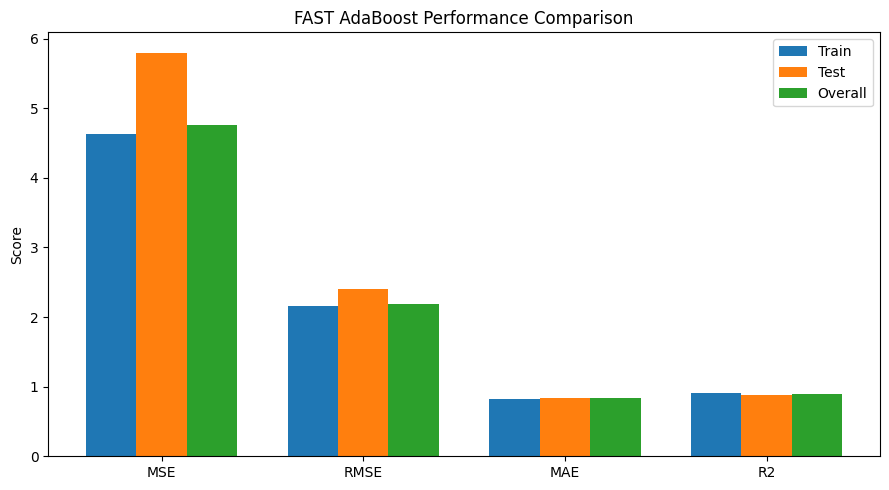

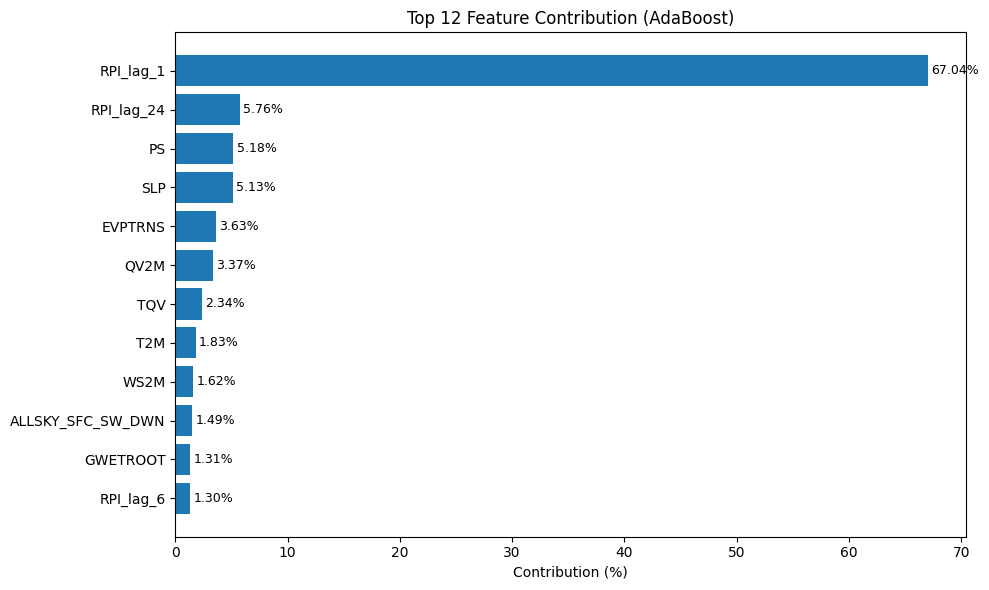

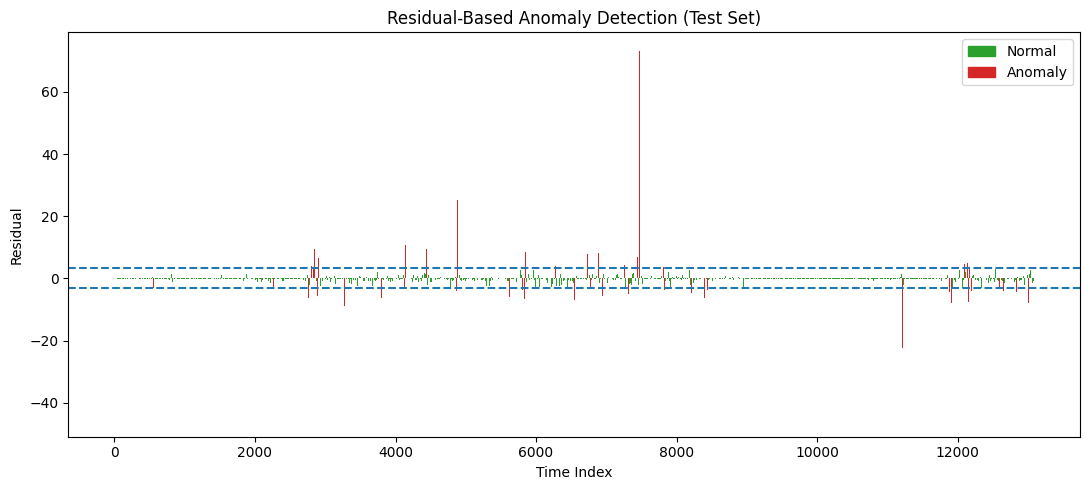

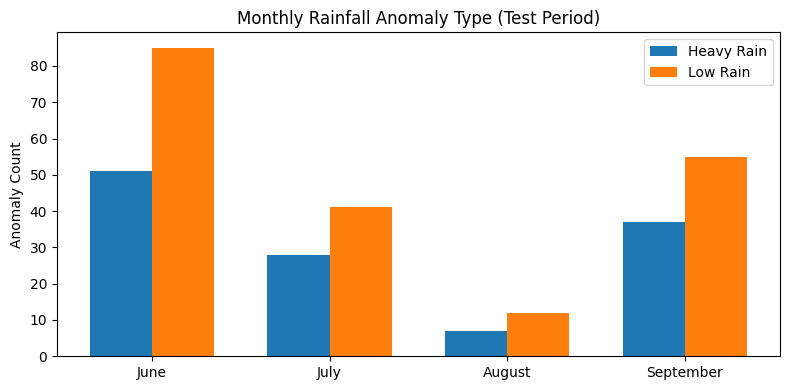

Visualizing Latest Available Year: 2024


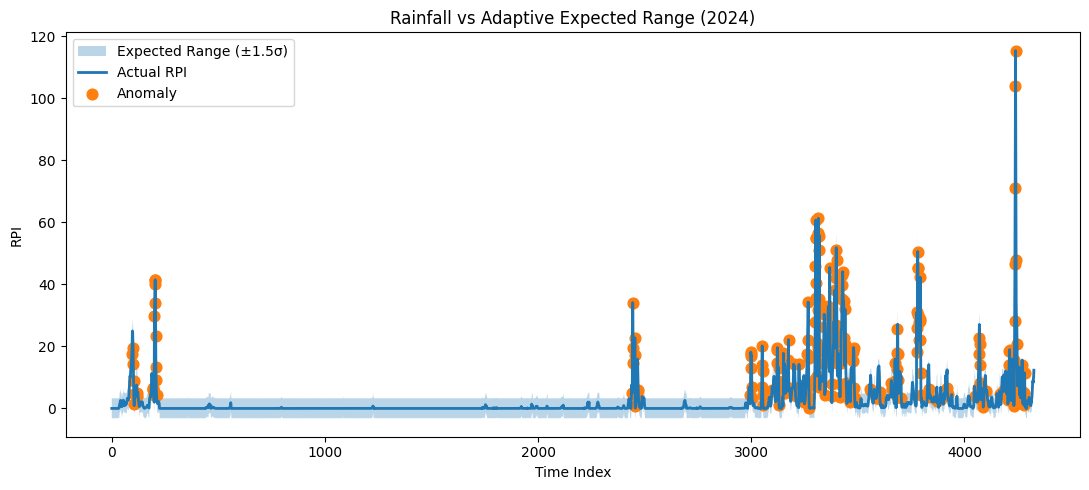

In [ ]:
# ==========================================================
# VISUALIZATION SECTION – FAST AdaBoost
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# ----------------------------------------------------------
# 1️⃣ Model Performance Comparison
# ----------------------------------------------------------

metrics = ["MSE", "RMSE", "MAE", "R2"]

train_scores = results_df.loc["Train"].values
test_scores = results_df.loc["Test"].values
overall_scores = results_df.loc["Overall"].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, train_scores, width, label="Train")
plt.bar(x, test_scores, width, label="Test")
plt.bar(x + width, overall_scores, width, label="Overall")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("FAST AdaBoost Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 2️⃣ Feature Importance (Top 12)
# ----------------------------------------------------------

importance = final_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_cols,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

top_features = feature_importance_df.head(12).copy()

top_features["Contribution (%)"] = (
    top_features["Importance"] /
    top_features["Importance"].sum()
) * 100

top_features = top_features.iloc[::-1]

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Contribution (%)"])

plt.xlabel("Contribution (%)")
plt.title("Top 12 Feature Contribution (AdaBoost)")

for i, v in enumerate(top_features["Contribution (%)"]):
    plt.text(v + 0.3, i, f"{v:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()




# ----------------------------------------------------------
# 4️⃣ Residual-Based Anomaly Classification (Test Set)
# ----------------------------------------------------------

plt.figure(figsize=(11,5))

colors = ["#2ca02c" if a == 0 else "#d62728" for a in test_df["Anomaly"]]

plt.bar(range(len(test_df)), test_df["Residual"], color=colors)

plt.axhline(threshold, linestyle='--')
plt.axhline(-threshold, linestyle='--')

normal_patch = mpatches.Patch(color="#2ca02c", label='Normal')
anomaly_patch = mpatches.Patch(color="#d62728", label='Anomaly')

plt.legend(handles=[normal_patch, anomaly_patch])

plt.title("Residual-Based Anomaly Detection (Test Set)")
plt.xlabel("Time Index")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 5️⃣ Monthly Positive vs Negative Anomalies (Test Set)
# ----------------------------------------------------------

monthly_split = (
    test_df
    .groupby("MONTH")[["Positive_Anomaly", "Negative_Anomaly"]]
    .sum()
)

# Keep monsoon months only if they exist
monsoon_months = [6,7,8,9]
available_monsoon = [m for m in monsoon_months if m in monthly_split.index]

monthly_split = monthly_split.loc[available_monsoon]

month_labels = ["June", "July", "August", "September"][:len(available_monsoon)]

x = np.arange(len(available_monsoon))
width = 0.35

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    monthly_split["Positive_Anomaly"],
    width,
    label="Heavy Rain"
)

plt.bar(
    x + width/2,
    monthly_split["Negative_Anomaly"],
    width,
    label="Low Rain"
)

plt.xticks(x, month_labels)
plt.ylabel("Anomaly Count")
plt.title("Monthly Rainfall Anomaly Type (Test Period)")
plt.legend()

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 6️⃣ Latest Available Year Deep Dive (Lag-Safe)
# ----------------------------------------------------------

latest_year = df["YEAR"].max()
print("Visualizing Latest Available Year:", latest_year)

year_df = df[df["YEAR"] == latest_year].copy()

if not year_df.empty:

    X_year = year_df[X_cols]
    y_year = year_df["RPI"].values
    y_pred_year = final_model.predict(X_year)

    residuals_year = y_year - y_pred_year
    anomaly_year = np.abs(residuals_year) > threshold

    plt.figure(figsize=(11,5))

    plt.fill_between(
        range(len(y_year)),
        y_pred_year - threshold,
        y_pred_year + threshold,
        alpha=0.3,
        label="Expected Range (±1.5σ)"
    )

    plt.plot(y_year, linewidth=2, label="Actual RPI")

    plt.scatter(
        np.where(anomaly_year),
        y_year[anomaly_year],
        s=60,
        label="Anomaly"
    )

    plt.title(f"Rainfall vs Adaptive Expected Range ({latest_year})")
    plt.xlabel("Time Index")
    plt.ylabel("RPI")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("No rows available for latest year after lag processing.")

# **Random Forest**

In [ ]:
# ==========================================================
# FAST & SAFE Random Forest (Lag-Based RPI Model)
# With Bayesian Hyperparameter Optimization
# ==========================================================

import pandas as pd
import numpy as np
import optuna
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------
df = pd.read_csv('/content/FINAL_DATASET_WITH_ROLLING.csv')

# ------------------------------------------------
# 2. Create Lag Features (on RPI)
# ------------------------------------------------
lags = [1, 3, 6, 24]

for lag in lags:
    df[f'RPI_lag_{lag}'] = df['RPI'].shift(lag)

df = df.dropna().reset_index(drop=True)

# ------------------------------------------------
# 3. Define Features
# ------------------------------------------------
raw_features = [
    'RH2M', 'QV2M', 'TQV', 'T2M', 'PS', 'SLP',
    'U2M', 'V2M', 'WS2M',
    'GWETROOT', 'GWETPROF',
    'EVPTRNS', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN'
]

lag_features = [f'RPI_lag_{l}' for l in lags]

X_cols = raw_features + lag_features
y_col = 'RPI'

# ------------------------------------------------
# 4. Chronological Split
# ------------------------------------------------
train_df = df[df['YEAR'] <= 2022].copy()
test_df  = df[df['YEAR'] >= 2023].copy()

X_train, y_train = train_df[X_cols], train_df[y_col]
X_test, y_test = test_df[X_cols], test_df[y_col]
X_overall, y_overall = df[X_cols], df[y_col]

# ------------------------------------------------
# 5. Bayesian Hyperparameter Tuning (Optimized Range)
# ------------------------------------------------
def objective(trial):

    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 150, 350),
        max_depth=trial.suggest_int("max_depth", 6, 15),
        min_samples_split=trial.suggest_int("min_samples_split", 20, 80),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 40),
        max_features=trial.suggest_float("max_features", 0.3, 0.8),
        max_samples=trial.suggest_float("max_samples", 0.6, 0.9),
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    return mean_squared_error(y_test, preds)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)  # Balanced speed + quality

print("\nBest Hyperparameters:")
print(study.best_params)

# ------------------------------------------------
# 6. Train Final Optimized Model
# ------------------------------------------------
best = study.best_params

final_model = RandomForestRegressor(
    n_estimators=best["n_estimators"],
    max_depth=best["max_depth"],
    min_samples_split=best["min_samples_split"],
    min_samples_leaf=best["min_samples_leaf"],
    max_features=best["max_features"],
    max_samples=best["max_samples"],
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Final Bayesian RF Model...")
start_time = time.time()
final_model.fit(X_train, y_train)
duration = time.time() - start_time

# ------------------------------------------------
# 7. Evaluation
# ------------------------------------------------
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [mse, rmse, mae, r2]

train_metrics = evaluate(y_train, final_model.predict(X_train))
test_metrics = evaluate(y_test, final_model.predict(X_test))
overall_metrics = evaluate(y_overall, final_model.predict(X_overall))

results_df = pd.DataFrame(
    [train_metrics, test_metrics, overall_metrics],
    index=["Train", "Test", "Overall"],
    columns=["MSE", "RMSE", "MAE", "R2"]
)

print(f"\nTraining Duration: {duration:.2f} seconds")
print("\nFAST Random Forest Results")
print(results_df)
print("\nOOB Score:", round(final_model.oob_score_, 4))

# ------------------------------------------------
# 8. Feature Importance
# ------------------------------------------------
importances = pd.Series(
    final_model.feature_importances_,
    index=X_cols
).sort_values(ascending=False)

print("\nTop 5 Important Features:")
print(importances.head(5))

# ==========================================================
# 9. Residual-Based 1.5σ Adaptive Anomaly Detection
# ==========================================================

# Predictions
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)
y_pred_overall = final_model.predict(X_overall)

# Residuals
train_residuals = y_train - y_pred_train
test_residuals = y_test - y_pred_test
overall_residuals = y_overall - y_pred_overall

# Train-based adaptive threshold
sigma = np.std(train_residuals)
threshold = 1.5 * sigma

print("\nResidual Threshold (±1.5σ):", round(threshold, 4))

# Add to test_df
test_df = test_df.copy()

test_df["Predicted_RPI"] = y_pred_test
test_df["Residual"] = test_residuals
test_df["Anomaly"] = (np.abs(test_residuals) > threshold).astype(int)
test_df["Positive_Anomaly"] = (test_residuals > threshold).astype(int)
test_df["Negative_Anomaly"] = (test_residuals < -threshold).astype(int)

# ------------------------------------------------
# 10. Anomaly Summary
# ------------------------------------------------
total_obs = len(test_df)
total_anomalies = test_df["Anomaly"].sum()
positive_anomalies = test_df["Positive_Anomaly"].sum()
negative_anomalies = test_df["Negative_Anomaly"].sum()

print("\n===== RF ADAPTIVE ANOMALY SUMMARY (Test Set) =====")
print(f"Total Test Observations: {total_obs}")
print(f"Detected Anomalies: {total_anomalies}")
print(f"Anomaly Percentage: {100 * total_anomalies / total_obs:.2f}%")
print(f"Positive Anomalies (Extreme Rain): {positive_anomalies}")
print(f"Negative Anomalies (Low Rain): {negative_anomalies}")

[I 2026-02-26 11:10:48,998] A new study created in memory with name: no-name-63b492ad-efdc-42ac-8546-295db8a01d2f
[I 2026-02-26 11:11:01,354] Trial 0 finished with value: 5.392444152833509 and parameters: {'n_estimators': 194, 'max_depth': 13, 'min_samples_split': 20, 'min_samples_leaf': 18, 'max_features': 0.43229718752214263, 'max_samples': 0.623419185430319}. Best is trial 0 with value: 5.392444152833509.
[I 2026-02-26 11:11:24,444] Trial 1 finished with value: 5.235844539161052 and parameters: {'n_estimators': 164, 'max_depth': 15, 'min_samples_split': 31, 'min_samples_leaf': 12, 'max_features': 0.7263444911775401, 'max_samples': 0.6607372142914064}. Best is trial 1 with value: 5.235844539161052.
[I 2026-02-26 11:11:39,840] Trial 2 finished with value: 5.418128878054157 and parameters: {'n_estimators': 167, 'max_depth': 15, 'min_samples_split': 33, 'min_samples_leaf': 34, 'max_features': 0.48793410894155387, 'max_samples': 0.8708897609299231}. Best is trial 1 with value: 5.23584453


Best Hyperparameters:
{'n_estimators': 158, 'max_depth': 12, 'min_samples_split': 36, 'min_samples_leaf': 15, 'max_features': 0.6188311530966637, 'max_samples': 0.6900346794944956}

Training Final Bayesian RF Model...

Training Duration: 16.69 seconds

FAST Random Forest Results
              MSE      RMSE       MAE        R2
Train    3.880274  1.969841  0.540516  0.919841
Test     5.216303  2.283923  0.705082  0.893970
Overall  4.147673  2.036584  0.573453  0.914605

OOB Score: 0.905

Top 5 Important Features:
RPI_lag_1            0.757525
RPI_lag_3            0.175003
RPI_lag_6            0.036532
TQV                  0.014257
ALLSKY_SFC_SW_DWN    0.002095
dtype: float64

Residual Threshold (±1.5σ): 2.9548

===== RF ADAPTIVE ANOMALY SUMMARY (Test Set) =====
Total Test Observations: 26304
Detected Anomalies: 1402
Anomaly Percentage: 5.33%
Positive Anomalies (Extreme Rain): 684
Negative Anomalies (Low Rain): 718


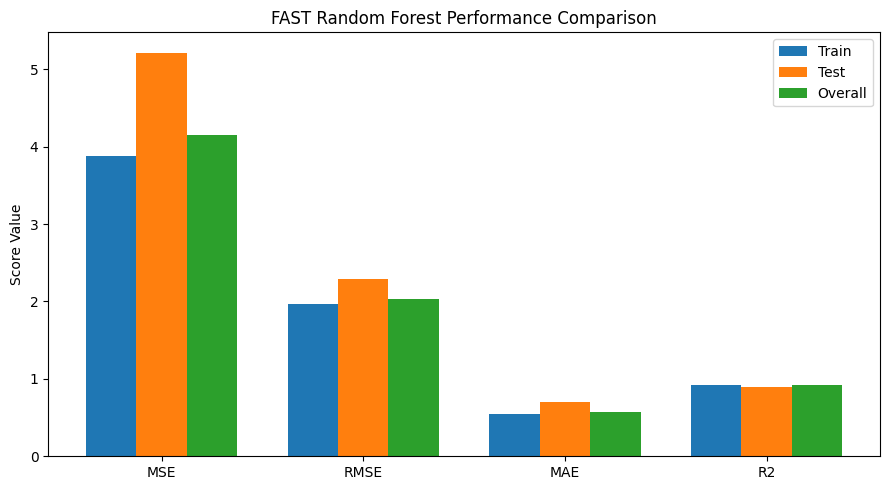

/tmp/ipython-input-2341/2560487769.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(contribution.index, rotation=40, ha="right")


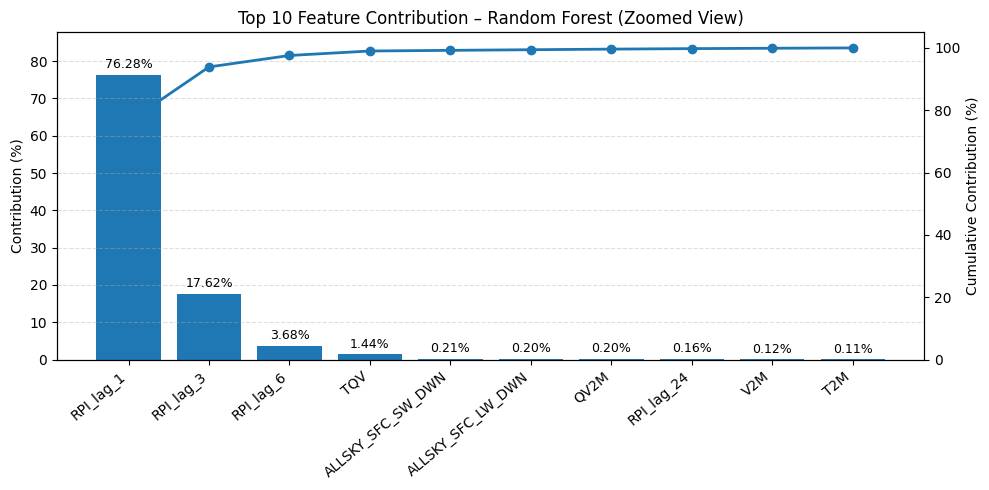

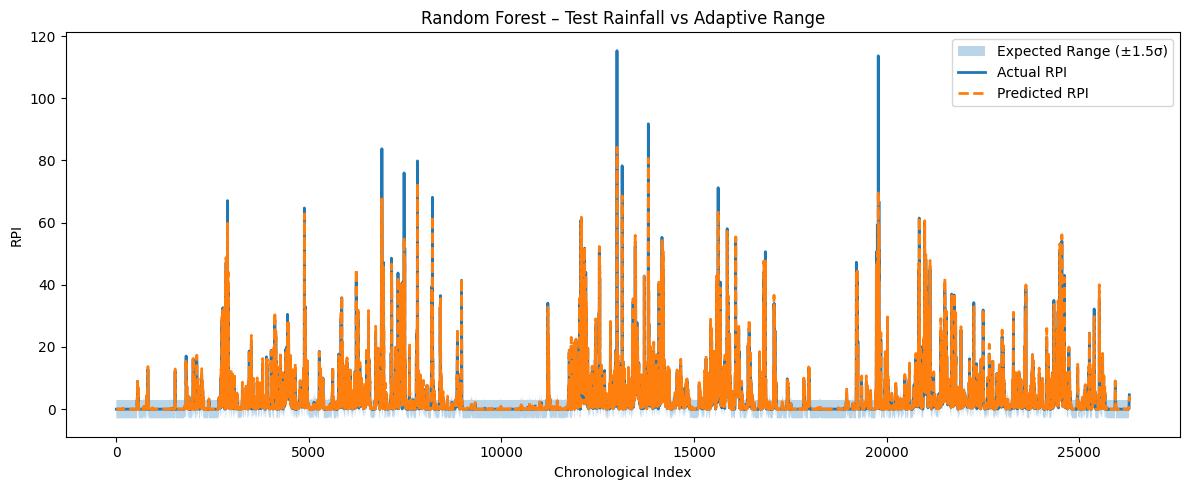

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


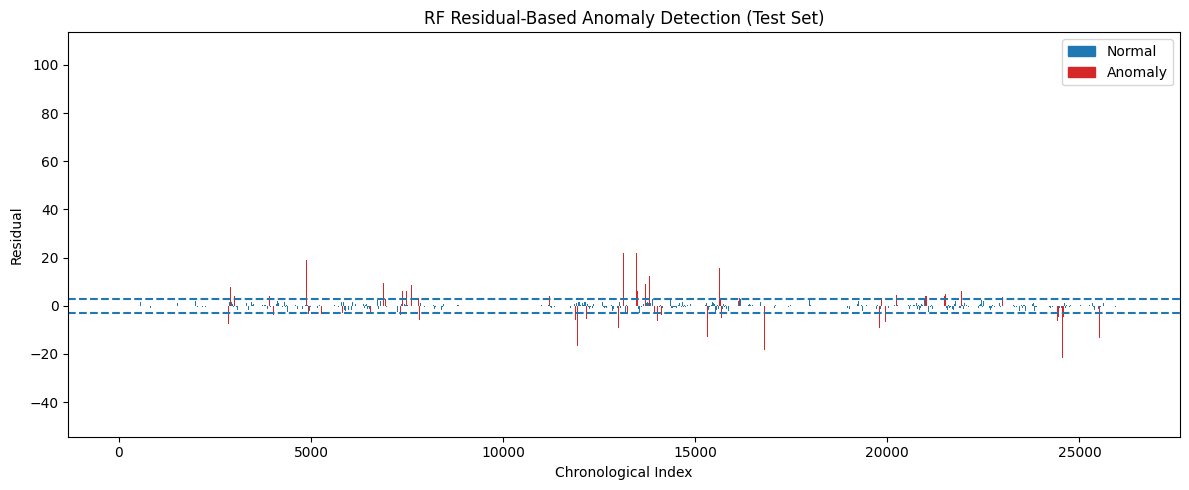

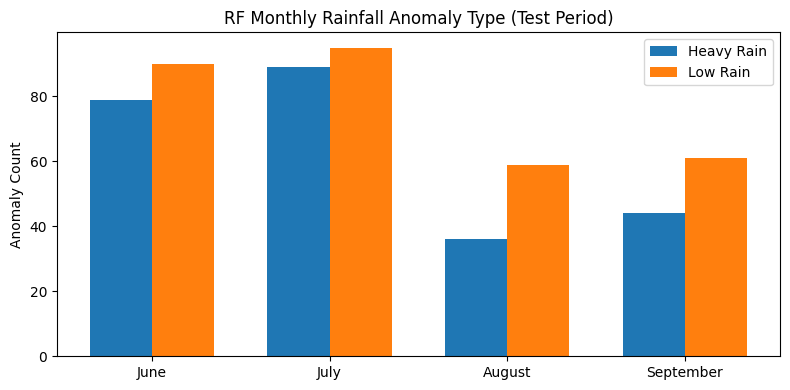

Visualizing Latest Available Year: 2025


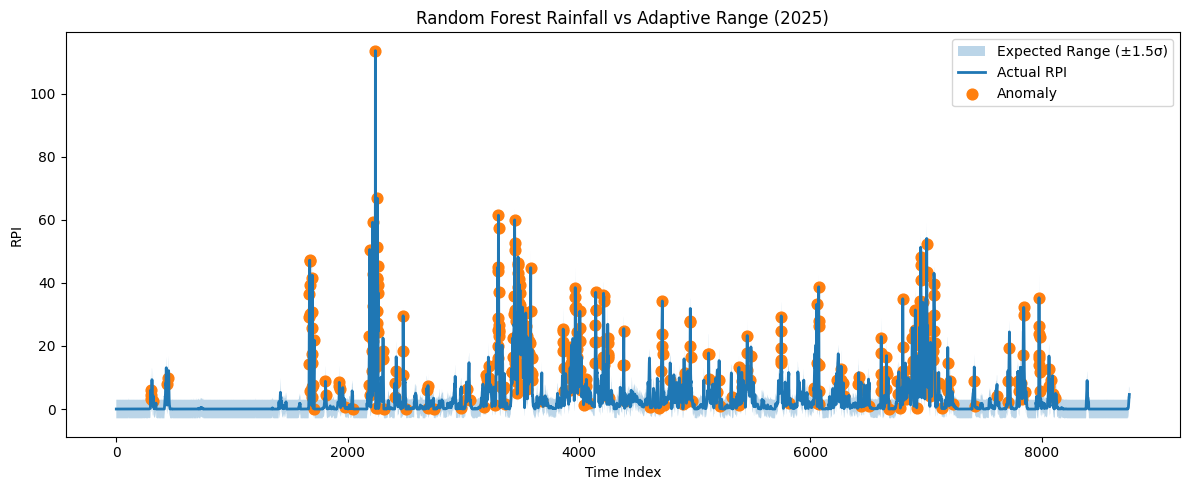

In [ ]:
# ==========================================================
# VISUALIZATION SECTION – FAST Random Forest
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

# ----------------------------------------------------------
# 1️⃣ Model Performance Comparison
# ----------------------------------------------------------

metrics = ["MSE", "RMSE", "MAE", "R2"]

train_scores = results_df.loc["Train"].values
test_scores = results_df.loc["Test"].values
overall_scores = results_df.loc["Overall"].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, train_scores, width, label="Train")
plt.bar(x, test_scores, width, label="Test")
plt.bar(x + width, overall_scores, width, label="Overall")

plt.xticks(x, metrics)
plt.ylabel("Score Value")
plt.title("FAST Random Forest Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 2️⃣ Advanced Feature Importance (Zoomed + Cumulative)
# ----------------------------------------------------------

# Sort feature importances
importances_sorted = importances.sort_values(ascending=False)

top_features = importances_sorted.head(10)

# Convert to percentage
contribution = (top_features / top_features.sum()) * 100
contribution = contribution.sort_values(ascending=False)

cumulative = contribution.cumsum()

# Dynamic zoom range
y_max = contribution.max() * 1.15

fig, ax1 = plt.subplots(figsize=(10,5))

bars = ax1.bar(contribution.index, contribution.values)

ax1.set_ylabel("Contribution (%)")
ax1.set_ylim(0, y_max)
ax1.set_title("Top 10 Feature Contribution – Random Forest (Zoomed View)")
ax1.set_xticklabels(contribution.index, rotation=40, ha="right")

# Add value labels
for i, v in enumerate(contribution.values):
    ax1.text(i, v + (y_max * 0.02), f"{v:.2f}%",
             ha='center', fontsize=9)

# Cumulative contribution line
ax2 = ax1.twinx()
ax2.plot(contribution.index, cumulative.values, marker='o', linewidth=2)
ax2.set_ylabel("Cumulative Contribution (%)")
ax2.set_ylim(0, 105)

# Grid styling
ax1.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 3️⃣ Test Set: Actual vs Predicted with Adaptive Band
# ----------------------------------------------------------

plt.figure(figsize=(12,5))

plt.fill_between(
    range(len(y_test)),
    y_pred_test - threshold,
    y_pred_test + threshold,
    alpha=0.3,
    label="Expected Range (±1.5σ)"
)

plt.plot(y_test.values, linewidth=2, label="Actual RPI")
plt.plot(y_pred_test, linewidth=2, linestyle="--", label="Predicted RPI")

plt.title("Random Forest – Test Rainfall vs Adaptive Range")
plt.xlabel("Chronological Index")
plt.ylabel("RPI")
plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 4️⃣ Residual-Based Anomaly Classification (Test Set)
# ----------------------------------------------------------

plt.figure(figsize=(12,5))

colors = ["#1f77b4" if a == 0 else "#d62728" for a in test_df["Anomaly"]]

plt.bar(range(len(test_df)), test_df["Residual"], color=colors)

plt.axhline(threshold, linestyle='--')
plt.axhline(-threshold, linestyle='--')

normal_patch = mpatches.Patch(color="#1f77b4", label='Normal')
anomaly_patch = mpatches.Patch(color="#d62728", label='Anomaly')

plt.legend(handles=[normal_patch, anomaly_patch])

plt.title("RF Residual-Based Anomaly Detection (Test Set)")
plt.xlabel("Chronological Index")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 5️⃣ Monthly Positive vs Negative Anomalies (Test Set)
# ----------------------------------------------------------

monthly_split = (
    test_df
    .groupby("MONTH")[["Positive_Anomaly", "Negative_Anomaly"]]
    .sum()
)

monsoon_months = [6,7,8,9]
available_monsoon = [m for m in monsoon_months if m in monthly_split.index]

monthly_split = monthly_split.loc[available_monsoon]

month_labels = ["June", "July", "August", "September"][:len(available_monsoon)]

x = np.arange(len(available_monsoon))
width = 0.35

plt.figure(figsize=(8,4))

plt.bar(
    x - width/2,
    monthly_split["Positive_Anomaly"],
    width,
    label="Heavy Rain"
)

plt.bar(
    x + width/2,
    monthly_split["Negative_Anomaly"],
    width,
    label="Low Rain"
)

plt.xticks(x, month_labels)
plt.ylabel("Anomaly Count")
plt.title("RF Monthly Rainfall Anomaly Type (Test Period)")
plt.legend()

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# 6️⃣ Latest Available Year Deep Dive (Lag-Safe)
# ----------------------------------------------------------

latest_year = df["YEAR"].max()
print("Visualizing Latest Available Year:", latest_year)

year_df = df[df["YEAR"] == latest_year].copy()

if not year_df.empty:

    X_year = year_df[X_cols]
    y_year = year_df["RPI"].values
    y_pred_year = final_model.predict(X_year)

    residuals_year = y_year - y_pred_year
    anomaly_year = np.abs(residuals_year) > threshold

    plt.figure(figsize=(12,5))

    plt.fill_between(
        range(len(y_year)),
        y_pred_year - threshold,
        y_pred_year + threshold,
        alpha=0.3,
        label="Expected Range (±1.5σ)"
    )

    plt.plot(y_year, linewidth=2, label="Actual RPI")

    plt.scatter(
        np.where(anomaly_year),
        y_year[anomaly_year],
        s=60,
        label="Anomaly"
    )

    plt.title(f"Random Forest Rainfall vs Adaptive Range ({latest_year})")
    plt.xlabel("Time Index")
    plt.ylabel("RPI")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("No rows available for latest year after lag processing.")

# **GradientBoostingRegressor**

[I 2026-02-26 11:39:26,750] A new study created in memory with name: no-name-ad88a464-dc35-4a3d-8d7f-1cbbd3ee97fc
[I 2026-02-26 11:39:40,893] Trial 0 finished with value: 5.3114702463442285 and parameters: {'n_estimators': 294, 'learning_rate': 0.07704285838459497, 'max_depth': 5, 'min_samples_split': 56, 'min_samples_leaf': 14, 'subsample': 0.7311989040672405, 'max_features': 0.4232334448672798}. Best is trial 0 with value: 5.3114702463442285.
[I 2026-02-26 11:40:01,685] Trial 1 finished with value: 5.384020435436001 and parameters: {'n_estimators': 417, 'learning_rate': 0.056066900704592526, 'max_depth': 5, 'min_samples_split': 21, 'min_samples_leaf': 40, 'subsample': 0.8664885281600844, 'max_features': 0.4849356442713105}. Best is trial 0 with value: 5.3114702463442285.
[I 2026-02-26 11:40:43,776] Trial 2 finished with value: 5.296033571193606 and parameters: {'n_estimators': 245, 'learning_rate': 0.03100427059120603, 'max_depth': 4, 'min_samples_split': 52, 'min_samples_leaf': 23, 


Best Hyperparameters: {'n_estimators': 450, 'learning_rate': 0.04874666366741848, 'max_depth': 6, 'min_samples_split': 39, 'min_samples_leaf': 17, 'subsample': 0.898390955002274, 'max_features': 0.6847911208853648}

Training Duration: 30.05 seconds

Gradient Boosting Results
              MSE      RMSE       MAE        R2
Train    3.529973  1.878822  0.590351  0.927078
Test     5.148652  2.269064  0.736195  0.895345
Overall  3.853943  1.963146  0.619540  0.920653

Adaptive Threshold (±1.2σ): 2.2546


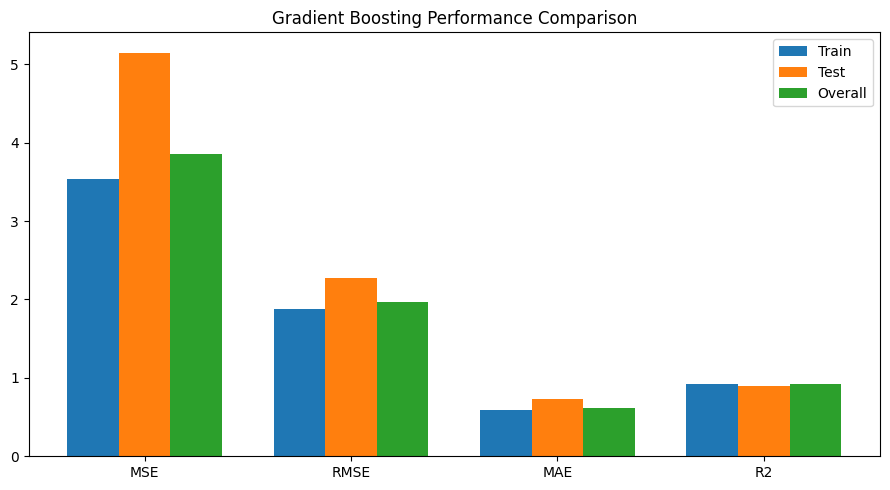

/tmp/ipython-input-2341/1712813291.py:188: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(contribution.index, rotation=45, ha="right")


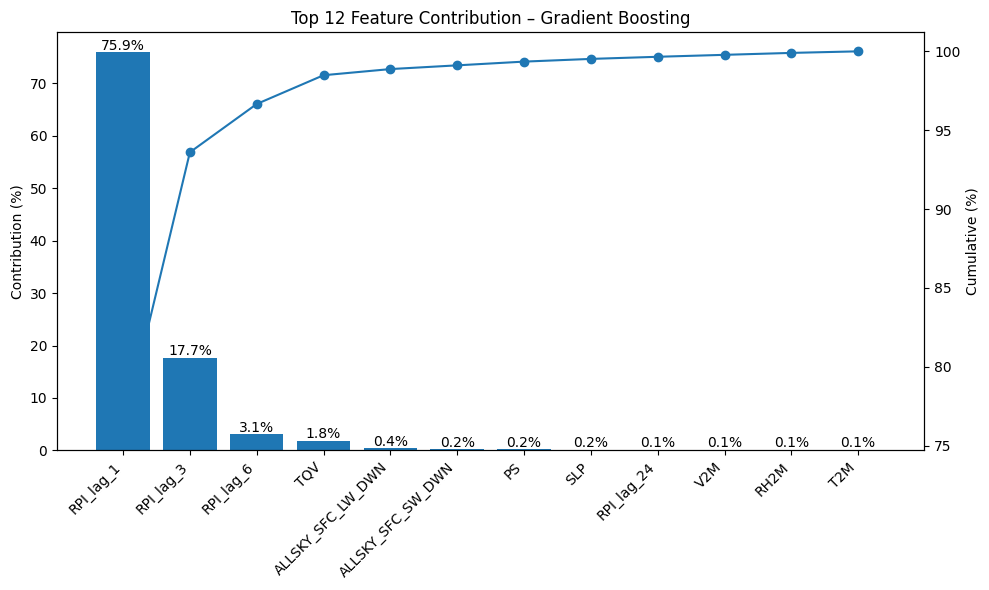

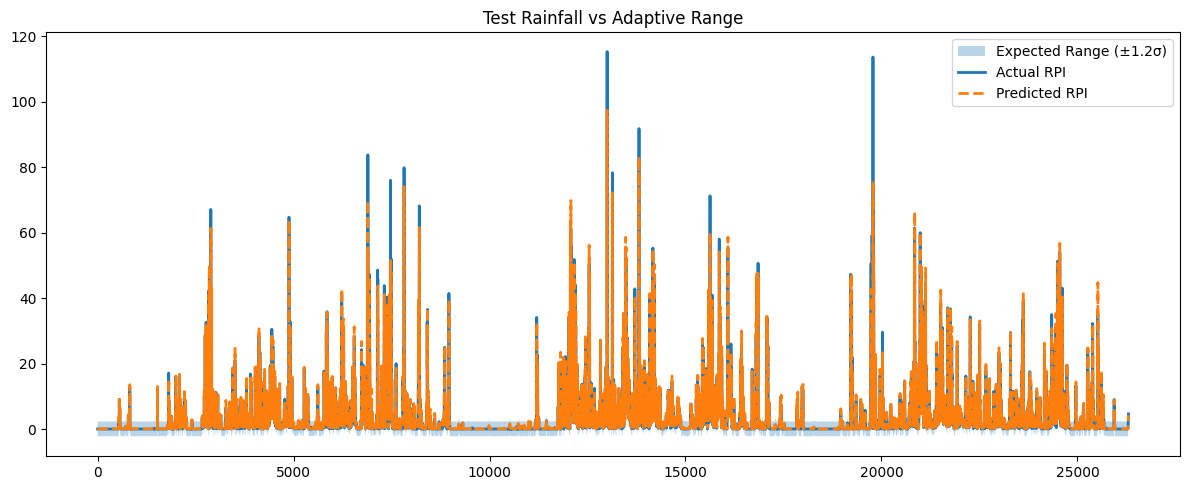

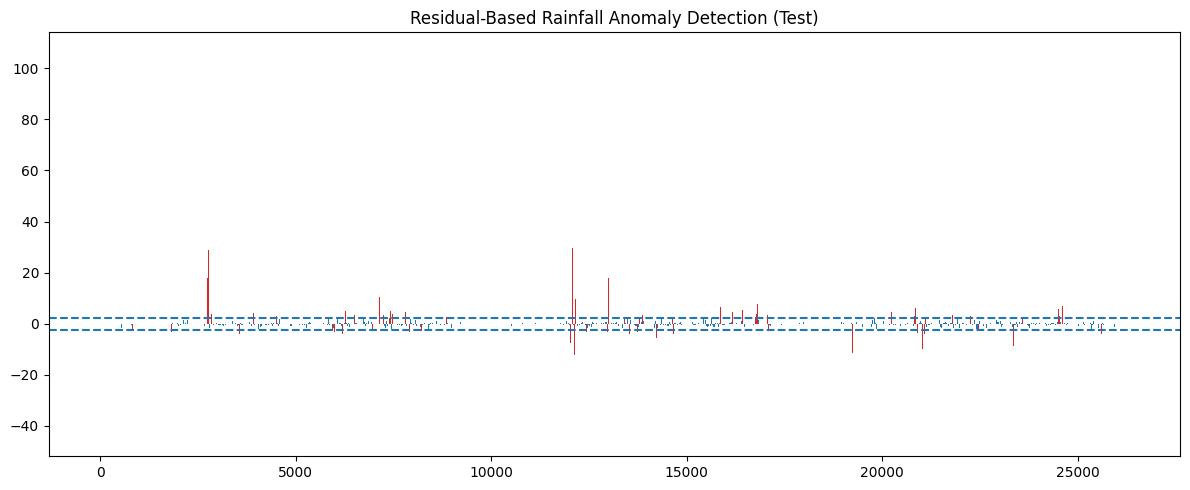

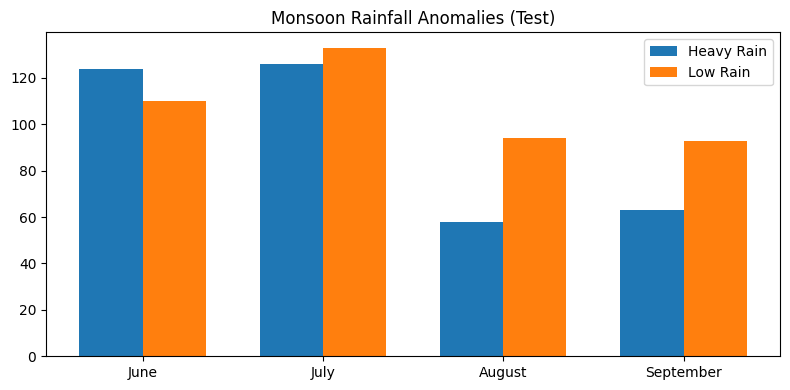

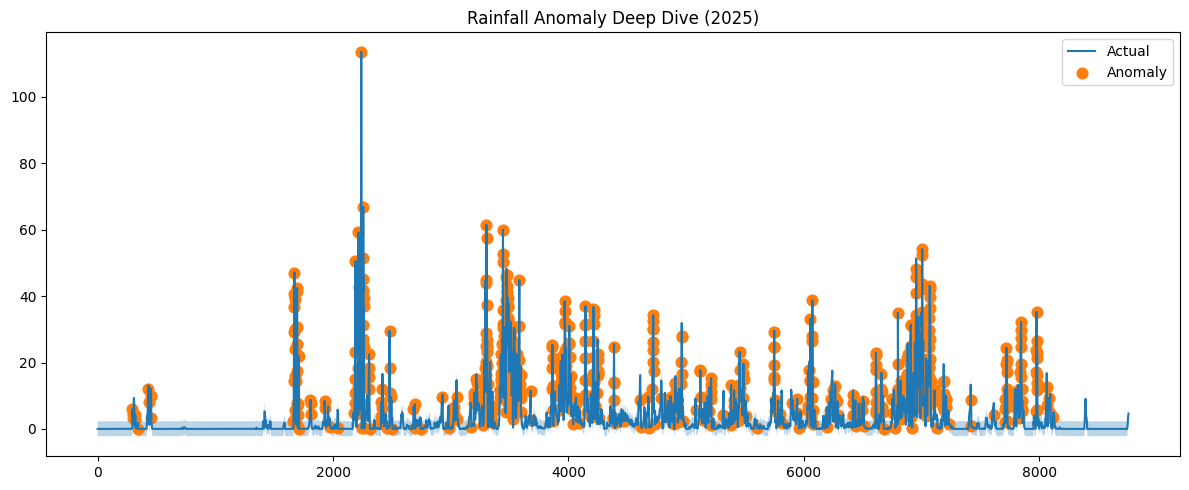

In [ ]:
import pandas as pd
import numpy as np
import optuna
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------
# 1️⃣ Load Dataset
# ------------------------------------------------
df = pd.read_csv('/content/FINAL_DATASET_WITH_ROLLING.csv')

# ------------------------------------------------
# 2️⃣ Create Lag Features
# ------------------------------------------------
lags = [1, 3, 6, 24]

for lag in lags:
    df[f'RPI_lag_{lag}'] = df['RPI'].shift(lag)

df = df.dropna().reset_index(drop=True)

# ------------------------------------------------
# 3️⃣ Feature Selection
# ------------------------------------------------
raw_features = [
    'RH2M','QV2M','TQV','T2M','PS','SLP',
    'U2M','V2M','WS2M',
    'GWETROOT','GWETPROF',
    'EVPTRNS','ALLSKY_SFC_SW_DWN','ALLSKY_SFC_LW_DWN'
]

lag_features = [f'RPI_lag_{l}' for l in lags]

X_cols = raw_features + lag_features
y_col = 'RPI'

# ------------------------------------------------
# 4️⃣ Chronological Split
# ------------------------------------------------
train_df = df[df['YEAR'] <= 2022].copy()
test_df  = df[df['YEAR'] >= 2023].copy()

X_train, y_train = train_df[X_cols], train_df[y_col]
X_test, y_test = test_df[X_cols], test_df[y_col]
X_all, y_all = df[X_cols], df[y_col]

# ------------------------------------------------
# 5️⃣ Scaling (FIT ONLY ON TRAIN)
# ------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X_all)

# ------------------------------------------------
# 6️⃣ Bayesian Optimization
# ------------------------------------------------
def objective(trial):
    model = GradientBoostingRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 450),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.08),
        max_depth=trial.suggest_int("max_depth", 3, 6),
        min_samples_split=trial.suggest_int("min_samples_split", 20, 80),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 10, 40),
        subsample=trial.suggest_float("subsample", 0.7, 0.9),
        max_features=trial.suggest_float("max_features", 0.4, 0.8),
        n_iter_no_change=10,
        validation_fraction=0.1,
        tol=1e-4,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    return mean_squared_error(y_test, preds)

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study.optimize(objective, n_trials=15)

best = study.best_params
print("\nBest Hyperparameters:", best)

# ------------------------------------------------
# 7️⃣ Train Final Model
# ------------------------------------------------
final_model = GradientBoostingRegressor(
    **best,
    n_iter_no_change=10,
    validation_fraction=0.1,
    tol=1e-4,
    random_state=42
)

start = time.time()
final_model.fit(X_train_scaled, y_train)
duration = time.time() - start

# ------------------------------------------------
# 8️⃣ Evaluation
# ------------------------------------------------
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [mse, rmse, mae, r2]

train_metrics = evaluate(y_train, final_model.predict(X_train_scaled))
test_metrics = evaluate(y_test, final_model.predict(X_test_scaled))
overall_metrics = evaluate(y_all, final_model.predict(X_all_scaled))

results_df = pd.DataFrame(
    [train_metrics, test_metrics, overall_metrics],
    index=["Train", "Test", "Overall"],
    columns=["MSE", "RMSE", "MAE", "R2"]
)

print(f"\nTraining Duration: {duration:.2f} seconds")
print("\nGradient Boosting Results")
print(results_df)

# ==========================================================
# 9️⃣ Sensitive Rainfall Anomaly Detection (±1.2σ)
# ==========================================================

train_df["Predicted_RPI"] = final_model.predict(X_train_scaled)
test_df["Predicted_RPI"]  = final_model.predict(X_test_scaled)
df["Predicted_RPI"]       = final_model.predict(X_all_scaled)

train_df["Residual"] = train_df["RPI"] - train_df["Predicted_RPI"]
test_df["Residual"]  = test_df["RPI"] - test_df["Predicted_RPI"]
df["Residual"]       = df["RPI"] - df["Predicted_RPI"]

threshold = 1.2 * train_df["Residual"].std()
print(f"\nAdaptive Threshold (±1.2σ): {threshold:.4f}")

def classify(res):
    if res > threshold:
        return 1
    elif res < -threshold:
        return -1
    return 0

for dataset in [train_df, test_df, df]:
    dataset["Anomaly"] = dataset["Residual"].apply(classify)
    dataset["Positive_Anomaly"] = (dataset["Anomaly"] == 1).astype(int)
    dataset["Negative_Anomaly"] = (dataset["Anomaly"] == -1).astype(int)

# ==========================================================
# 🔟 VISUALIZATION SECTION
# ==========================================================

# 1️⃣ Performance Comparison
metrics = ["MSE", "RMSE", "MAE", "R2"]
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, results_df.loc["Train"], width, label="Train")
plt.bar(x, results_df.loc["Test"], width, label="Test")
plt.bar(x + width, results_df.loc["Overall"], width, label="Overall")
plt.xticks(x, metrics)
plt.title("Gradient Boosting Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 2️⃣ Feature Importance (Top 12)
importances = pd.Series(final_model.feature_importances_, index=X_cols)
top_features = importances.sort_values(ascending=False).head(12)
contribution = (top_features / top_features.sum()) * 100
cumulative = contribution.cumsum()

fig, ax1 = plt.subplots(figsize=(10,6))
ax1.bar(contribution.index, contribution.values)
ax1.set_ylabel("Contribution (%)")
ax1.set_xticklabels(contribution.index, rotation=45, ha="right")

for i, v in enumerate(contribution.values):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha="center")

ax2 = ax1.twinx()
ax2.plot(contribution.index, cumulative.values, marker="o")
ax2.set_ylabel("Cumulative (%)")
plt.title("Top 12 Feature Contribution – Gradient Boosting")
plt.tight_layout()
plt.show()

# 3️⃣ Test: Actual vs Predicted + Sensitive Band
plt.figure(figsize=(12,5))
y_pred_test = final_model.predict(X_test_scaled)

plt.fill_between(
    range(len(y_test)),
    y_pred_test - threshold,
    y_pred_test + threshold,
    alpha=0.3,
    label="Expected Range (±1.2σ)"
)

plt.plot(y_test.values, label="Actual RPI", linewidth=2)
plt.plot(y_pred_test, linestyle="--", label="Predicted RPI", linewidth=2)
plt.legend()
plt.title("Test Rainfall vs Adaptive Range")
plt.tight_layout()
plt.show()

# 4️⃣ Residual-Based Anomaly Plot
plt.figure(figsize=(12,5))
colors = ["#1f77b4" if a == 0 else "#d62728" for a in test_df["Anomaly"]]
plt.bar(range(len(test_df)), test_df["Residual"], color=colors)
plt.axhline(threshold, linestyle="--")
plt.axhline(-threshold, linestyle="--")
plt.title("Residual-Based Rainfall Anomaly Detection (Test)")
plt.tight_layout()
plt.show()

# 5️⃣ Monthly Monsoon Anomalies
monthly = (
    test_df.groupby("MONTH")[["Positive_Anomaly","Negative_Anomaly"]]
    .sum()
)

monsoon = [6,7,8,9]
available = [m for m in monsoon if m in monthly.index]
monthly = monthly.loc[available]

x = np.arange(len(available))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, monthly["Positive_Anomaly"], width, label="Heavy Rain")
plt.bar(x + width/2, monthly["Negative_Anomaly"], width, label="Low Rain")
plt.xticks(x, ["June","July","August","September"][:len(available)])
plt.legend()
plt.title("Monsoon Rainfall Anomalies (Test)")
plt.tight_layout()
plt.show()

# 6️⃣ Latest Year Deep Dive
latest_year = df["YEAR"].max()
year_df = df[df["YEAR"] == latest_year]

if not year_df.empty:
    X_year = scaler.transform(year_df[X_cols])
    y_year = year_df["RPI"].values
    y_pred_year = final_model.predict(X_year)

    residual_year = y_year - y_pred_year
    anomaly_year = np.abs(residual_year) > threshold

    plt.figure(figsize=(12,5))
    plt.fill_between(
        range(len(y_year)),
        y_pred_year - threshold,
        y_pred_year + threshold,
        alpha=0.3
    )
    plt.plot(y_year, label="Actual")
    plt.scatter(np.where(anomaly_year), y_year[anomaly_year], s=60, label="Anomaly")
    plt.title(f"Rainfall Anomaly Deep Dive ({latest_year})")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No rows available for latest year.")

**PROPROCESED MODEL**

# ***Random Forest + GradientBoosting***

In [ ]:
import pandas as pd
import optuna
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------
# 1️⃣ Load dataset
# ------------------------------
df = pd.read_csv('/content/FINAL_DATASET_WITH_ROLLING.csv')

# ------------------------------
# 2️⃣ Select lag + rolling features
# ------------------------------
feature_cols = [
    'rain_lag_1hr', 'rain_lag_3hr', 'rain_lag_6hr', 'rain_lag_24hr',
    'rain_roll_3', 'rain_roll_6', 'rain_roll_24',
    'soil_root_roll_6', 'soil_root_roll_24',
    'temp_roll_6', 'temp_roll_24'
]

X = df[feature_cols]
y = df['RPI']

# ------------------------------
# 3️⃣ Chronological split (better for climate)
# ------------------------------
train_df = df[df['YEAR'] <= 2022].copy()
test_df  = df[df['YEAR'] >= 2023].copy()

X_train = train_df[feature_cols]
y_train = train_df['RPI']
X_test  = test_df[feature_cols]
y_test  = test_df['RPI']

# ------------------------------
# 4️⃣ Sample 20% of training for fast tuning
# ------------------------------
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=0.2, random_state=42
)

# ------------------------------
# 5️⃣ Optuna objective
# ------------------------------
def objective(trial):

    rf = RandomForestRegressor(
        n_estimators=trial.suggest_int('rf_n_estimators', 50, 200),
        max_depth=trial.suggest_int('rf_max_depth', 3, 10),
        n_jobs=-1,
        random_state=42
    )

    gb = GradientBoostingRegressor(
        n_estimators=trial.suggest_int('gb_n_estimators', 50, 200),
        learning_rate=trial.suggest_float('gb_learning_rate', 0.05, 0.2),
        max_depth=trial.suggest_int('gb_max_depth', 3, 6),
        random_state=42
    )

    rf.fit(X_sample, y_sample)
    gb.fit(X_sample, y_sample)

    y_pred = 0.6*rf.predict(X_sample) + 0.4*gb.predict(X_sample)

    return np.sqrt(mean_squared_error(y_sample, y_pred))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

best = study.best_params
print("Best hyperparameters:", best)

# ------------------------------
# 6️⃣ Train final models
# ------------------------------
rf_best = RandomForestRegressor(
    n_estimators=best['rf_n_estimators'],
    max_depth=best['rf_max_depth'],
    n_jobs=-1,
    random_state=42
)

gb_best = GradientBoostingRegressor(
    n_estimators=best['gb_n_estimators'],
    learning_rate=best['gb_learning_rate'],
    max_depth=best['gb_max_depth'],
    random_state=42
)

rf_best.fit(X_train, y_train)
gb_best.fit(X_train, y_train)

# ------------------------------
# 7️⃣ Hybrid Predictions
# ------------------------------
y_pred_train = 0.6*rf_best.predict(X_train) + 0.4*gb_best.predict(X_train)
y_pred_test  = 0.6*rf_best.predict(X_test)  + 0.4*gb_best.predict(X_test)

# ------------------------------
# 8️⃣ Performance Evaluation
# ------------------------------
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

mse, rmse, mae, r2 = evaluate(y_test, y_pred_test)

print("\nHybrid RF + GB Results")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# ======================================================
# 🌧 9️⃣ Rainfall Anomaly Detection (±1.2σ)
# ======================================================

train_df["Predicted_RPI"] = y_pred_train
test_df["Predicted_RPI"]  = y_pred_test

train_df["Residual"] = train_df["RPI"] - train_df["Predicted_RPI"]
test_df["Residual"]  = test_df["RPI"] - test_df["Predicted_RPI"]

threshold = 1.2 * train_df["Residual"].std()
print(f"\nAdaptive Threshold (±1.2σ): {threshold:.4f}")

def classify(res):
    if res > threshold:
        return 1
    elif res < -threshold:
        return -1
    return 0

test_df["Anomaly"] = test_df["Residual"].apply(classify)
test_df["Positive_Anomaly"] = (test_df["Anomaly"] == 1).astype(int)
test_df["Negative_Anomaly"] = (test_df["Anomaly"] == -1).astype(int)

print("\nAnomaly Summary (Test)")
print("Normal:", (test_df["Anomaly"] == 0).sum())
print("Heavy Rain:", (test_df["Anomaly"] == 1).sum())
print("Low Rain:", (test_df["Anomaly"] == -1).sum())


[I 2026-02-26 15:08:59,628] A new study created in memory with name: no-name-0ded0d37-2f6c-41d7-abf1-eab5efaedf20
[I 2026-02-26 15:09:13,328] Trial 0 finished with value: 0.707653852743468 and parameters: {'rf_n_estimators': 178, 'rf_max_depth': 9, 'gb_n_estimators': 98, 'gb_learning_rate': 0.05629548198698876, 'gb_max_depth': 5}. Best is trial 0 with value: 0.707653852743468.
[I 2026-02-26 15:09:18,138] Trial 1 finished with value: 1.4028254886181466 and parameters: {'rf_n_estimators': 55, 'rf_max_depth': 3, 'gb_n_estimators': 50, 'gb_learning_rate': 0.07516694757885234, 'gb_max_depth': 5}. Best is trial 0 with value: 0.707653852743468.
[I 2026-02-26 15:09:25,998] Trial 2 finished with value: 1.0859127842803322 and parameters: {'rf_n_estimators': 154, 'rf_max_depth': 5, 'gb_n_estimators': 82, 'gb_learning_rate': 0.09410164492350914, 'gb_max_depth': 4}. Best is trial 0 with value: 0.707653852743468.
[I 2026-02-26 15:09:35,242] Trial 3 finished with value: 1.2748471377211057 and paramet

Best hyperparameters: {'rf_n_estimators': 107, 'rf_max_depth': 10, 'gb_n_estimators': 199, 'gb_learning_rate': 0.15565005714175098, 'gb_max_depth': 6}

Hybrid RF + GB Results
MSE: 1.4148
RMSE: 1.1895
MAE: 0.3841
R²: 0.9712

Adaptive Threshold (±1.2σ): 0.7835

Anomaly Summary (Test)
Normal: 23057
Heavy Rain: 1634
Low Rain: 1613


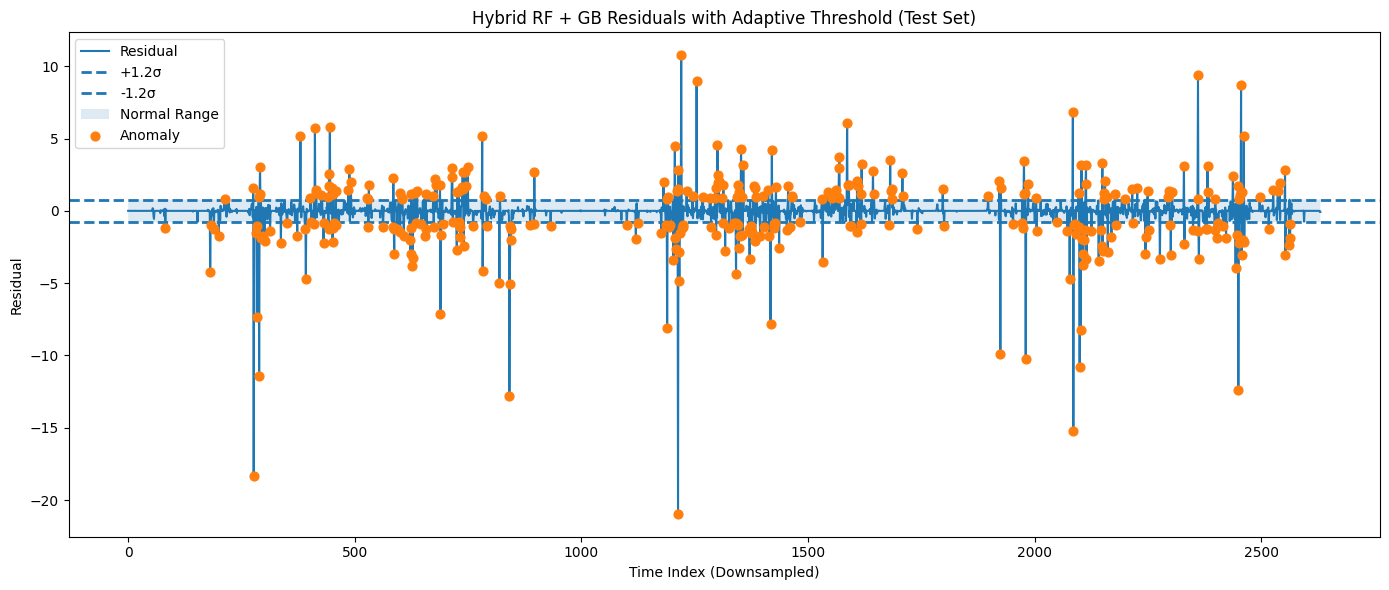

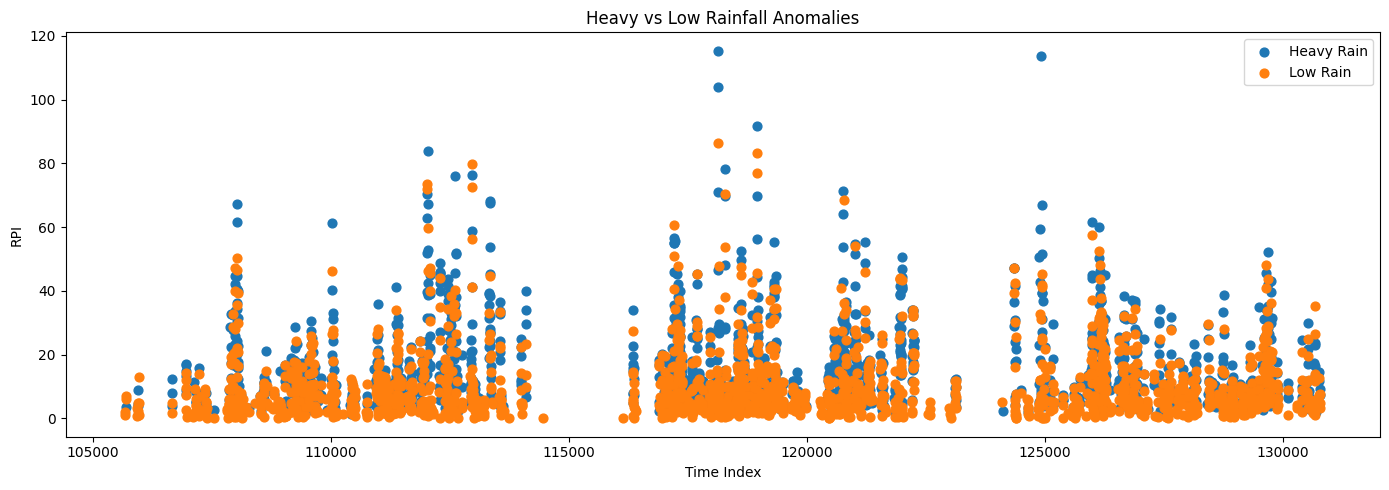

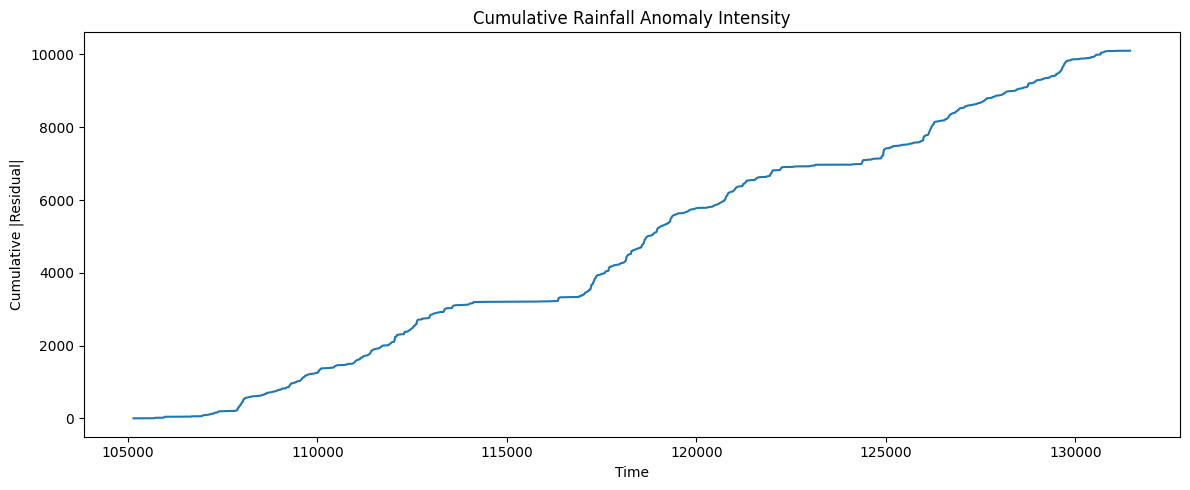

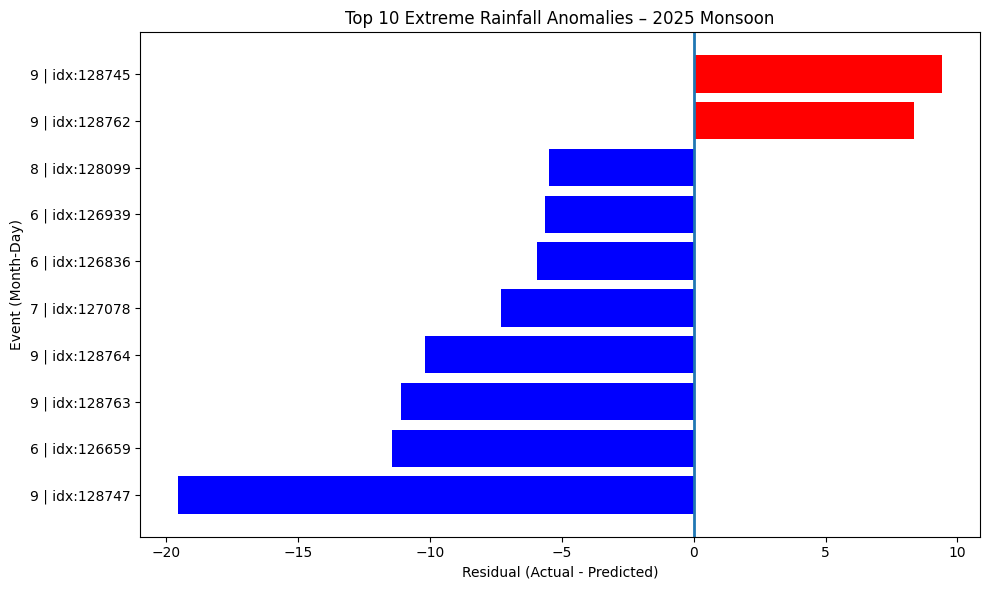

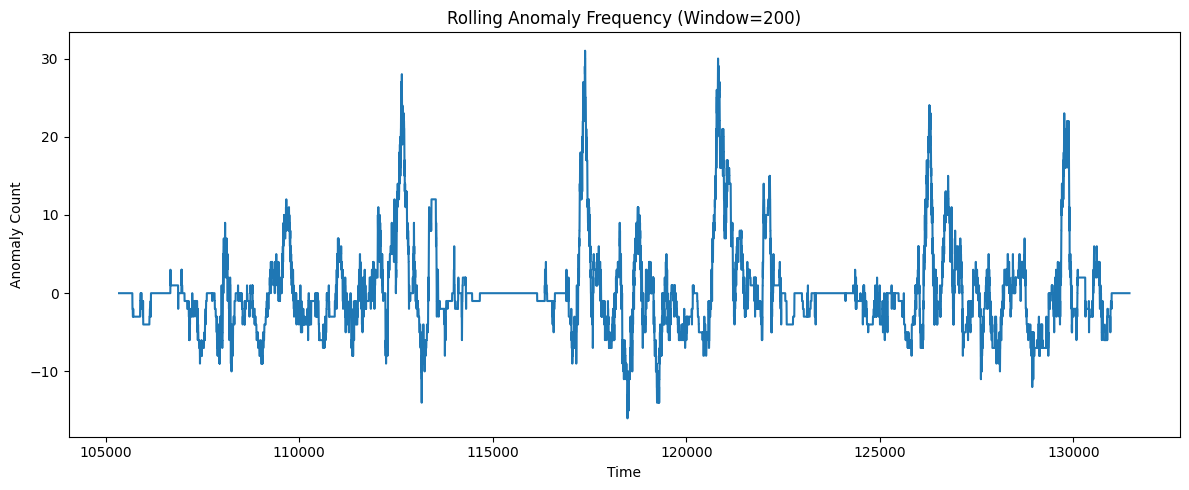

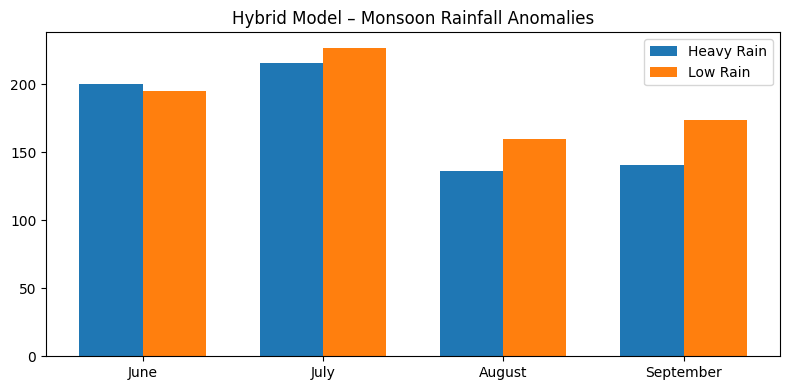

In [ ]:
# ============================================================
# HYBRID RF + GB ANOMALY VISUALIZATION SUITE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# GLOBAL SETTINGS
# ============================================================

threshold_line = threshold
monsoon_months = [6, 7, 8, 9]

# ============================================================
# 1️⃣ CLEAN RESIDUAL PLOT (DOWNSAMPLED)
# ============================================================

def plot_residuals(test_df, step=10):

    residual_ds = test_df["Residual"].values[::step]
    anomaly_ds  = test_df["Anomaly"].values[::step]
    x_axis = np.arange(len(residual_ds))

    plt.figure(figsize=(14,6))

    plt.plot(x_axis, residual_ds, linewidth=1.5, label="Residual")
    plt.axhline(threshold_line, linestyle="--", linewidth=2, label="+1.2σ")
    plt.axhline(-threshold_line, linestyle="--", linewidth=2, label="-1.2σ")

    plt.fill_between(
        x_axis,
        -threshold_line,
        threshold_line,
        alpha=0.15,
        label="Normal Range"
    )

    anomaly_idx = np.where(anomaly_ds != 0)

    plt.scatter(
        anomaly_idx,
        residual_ds[anomaly_idx],
        s=40,
        zorder=3,
        label="Anomaly"
    )

    plt.title("Hybrid RF + GB Residuals with Adaptive Threshold (Test Set)")
    plt.xlabel("Time Index (Downsampled)")
    plt.ylabel("Residual")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 2️⃣ HEAVY vs LOW RAIN SCATTER
# ============================================================

def plot_heavy_low(test_df):

    heavy = test_df["Anomaly"] == 1
    low   = test_df["Anomaly"] == -1

    plt.figure(figsize=(14,5))

    plt.scatter(test_df.index[heavy], test_df["RPI"][heavy], s=40, label="Heavy Rain")
    plt.scatter(test_df.index[low], test_df["RPI"][low], s=40, label="Low Rain")

    plt.title("Heavy vs Low Rainfall Anomalies")
    plt.xlabel("Time Index")
    plt.ylabel("RPI")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 3️⃣ CUMULATIVE ANOMALY INTENSITY
# ============================================================

def plot_cumulative_intensity(test_df):

    cumulative_intensity = np.cumsum(np.abs(test_df["Residual"]))

    plt.figure(figsize=(12,5))
    plt.plot(cumulative_intensity)
    plt.title("Cumulative Rainfall Anomaly Intensity")
    plt.xlabel("Time")
    plt.ylabel("Cumulative |Residual|")
    plt.tight_layout()
    plt.show()


# ============================================================
# 4️⃣ TOP 10 EXTREME MONSOON EVENTS (2025)
# ============================================================

def plot_top10_monsoon(test_df):

    monsoon_2025 = test_df[
        (test_df["YEAR"] == 2025) &
        (test_df["MONTH"].isin(monsoon_months))
    ].copy()

    top_10 = monsoon_2025.reindex(
        monsoon_2025["Residual"].abs()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    top_10 = top_10.sort_values(by="Residual")

    if "DAY" in top_10.columns:
        labels = top_10["MONTH"].astype(str) + "-" + top_10["DAY"].astype(str)
    else:
        labels = top_10["MONTH"].astype(str) + " | idx:" + top_10.index.astype(str)

    colors = ["red" if r > 0 else "blue" for r in top_10["Residual"]]

    plt.figure(figsize=(10,6))
    plt.barh(labels, top_10["Residual"], color=colors)
    plt.axvline(0, linewidth=2)

    plt.title("Top 10 Extreme Rainfall Anomalies – 2025 Monsoon")
    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Event (Month-Day)")
    plt.tight_layout()
    plt.show()


# ============================================================
# 5️⃣ ROLLING ANOMALY FREQUENCY
# ============================================================

def plot_rolling_anomaly(test_df, window=200):

    rolling_anomaly = test_df["Anomaly"].rolling(window).sum()

    plt.figure(figsize=(12,5))
    plt.plot(rolling_anomaly)
    plt.title(f"Rolling Anomaly Frequency (Window={window})")
    plt.xlabel("Time")
    plt.ylabel("Anomaly Count")
    plt.tight_layout()
    plt.show()


# ============================================================
# 6️⃣ MONTHLY MONSOON ANOMALY DISTRIBUTION
# ============================================================

def plot_monthly_monsoon(test_df):

    monthly = (
        test_df.groupby("MONTH")[["Positive_Anomaly","Negative_Anomaly"]]
        .sum()
    )

    available = [m for m in monsoon_months if m in monthly.index]
    monthly = monthly.loc[available]

    x = np.arange(len(available))
    width = 0.35

    plt.figure(figsize=(8,4))

    plt.bar(x - width/2, monthly["Positive_Anomaly"], width, label="Heavy Rain")
    plt.bar(x + width/2, monthly["Negative_Anomaly"], width, label="Low Rain")

    plt.xticks(x, ["June","July","August","September"][:len(available)])
    plt.legend()
    plt.title("Hybrid Model – Monsoon Rainfall Anomalies")
    plt.tight_layout()
    plt.show()


# ============================================================
# 🚀 RUN ALL PLOTS
# ============================================================

plot_residuals(test_df)
plot_heavy_low(test_df)
plot_cumulative_intensity(test_df)
plot_top10_monsoon(test_df)
plot_rolling_anomaly(test_df)
plot_monthly_monsoon(test_df)

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 613.9/613.9 kB 40.8 MB/s eta 0:00:00


In [ ]:
# ======================================================
# Fast Hybrid Random Forest + GradientBoosting (Lag + Rolling Features)
# ======================================================

import pandas as pd
import optuna
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # Import numpy for sqrt

# ------------------------------
# Step 1: Load dataset
# ------------------------------
df = pd.read_csv('/content/FINAL_DATASET_WITH_ROLLING.csv')  # Replace with your dataset path

# ------------------------------
# Step 2: Select lag + rolling features
# ------------------------------
feature_cols = [
    'rain_lag_1hr', 'rain_lag_3hr', 'rain_lag_6hr', 'rain_lag_24hr',
    'rain_roll_3', 'rain_roll_6', 'rain_roll_24',
    'soil_root_roll_6', 'soil_root_roll_24',
    'temp_roll_6', 'temp_roll_24'
]

X = df[feature_cols]
y = df['RPI']

# ------------------------------
# Step 3: Train-test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# Step 4: Sample 20% of training data for faster tuning
# ------------------------------
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=0.2, random_state=42)

# ------------------------------
# Step 5: Define Optuna objective (fast tuning)
# ------------------------------
def objective(trial):
    # Random Forest hyperparameters (smaller ranges)
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 50, 200)
    rf_max_depth = trial.suggest_int('rf_max_depth', 3, 10)

    # Gradient Boosting hyperparameters (smaller ranges)
    gb_n_estimators = trial.suggest_int('gb_n_estimators', 50, 200)
    gb_learning_rate = trial.suggest_float('gb_learning_rate', 0.05, 0.2)
    gb_max_depth = trial.suggest_int('gb_max_depth', 3, 6)

    # Initialize models
    rf = RandomForestRegressor(
        n_estimators=rf_n_estimators, max_depth=rf_max_depth,
        n_jobs=-1, random_state=42
    )
    gb = GradientBoostingRegressor(
        n_estimators=gb_n_estimators, learning_rate=gb_learning_rate,
        max_depth=gb_max_depth, random_state=42
    )

    # Train on the small sample
    rf.fit(X_sample, y_sample)
    gb.fit(X_sample, y_sample)

    # Weighted hybrid predictions
    y_pred = 0.6*rf.predict(X_sample) + 0.4*gb.predict(X_sample)

    # Minimize training RMSE
    # Calculate MSE first, then take square root for RMSE
    mse = mean_squared_error(y_sample, y_pred)
    rmse = np.sqrt(mse)
    return rmse

# ------------------------------
# Step 6: Run Optuna study
# ------------------------------
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)  # Fewer trials for speed

print("Best hyperparameters found:")
print(study.best_params)

# ------------------------------
# Step 7: Train final hybrid on full training set
# ------------------------------
best_params = study.best_params

rf_best = RandomForestRegressor(
    n_estimators=best_params['rf_n_estimators'],
    max_depth=best_params['rf_max_depth'],
    n_jobs=-1, random_state=42
)
gb_best = GradientBoostingRegressor(
    n_estimators=best_params['gb_n_estimators'],
    learning_rate=best_params['gb_learning_rate'],
    max_depth=best_params['gb_max_depth'],
    random_state=42
)

rf_best.fit(X_train, y_train)
gb_best.fit(X_train, y_train)

# ------------------------------
# Step 8: Weighted hybrid prediction on test set
# ------------------------------
y_pred_test = 0.6*rf_best.predict(X_test) + 0.4*gb_best.predict(X_test)

# ------------------------------
# Step 9: Evaluate performance
# ------------------------------
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse) # Use np.sqrt for RMSE
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nFast Hybrid RF + GB Results (Lag + Rolling Features)")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

[I 2026-02-24 17:33:06,208] A new study created in memory with name: no-name-0addcb0f-65ec-418d-97e5-b2c105b035f3
[I 2026-02-24 17:33:14,173] Trial 0 finished with value: 1.3402648497197809 and parameters: {'rf_n_estimators': 110, 'rf_max_depth': 4, 'gb_n_estimators': 128, 'gb_learning_rate': 0.08265993382670335, 'gb_max_depth': 3}. Best is trial 0 with value: 1.3402648497197809.
[I 2026-02-24 17:33:21,458] Trial 1 finished with value: 1.4441680159385182 and parameters: {'rf_n_estimators': 81, 'rf_max_depth': 3, 'gb_n_estimators': 95, 'gb_learning_rate': 0.06328589598083914, 'gb_max_depth': 4}. Best is trial 0 with value: 1.3402648497197809.
[I 2026-02-24 17:33:33,759] Trial 2 finished with value: 0.6274158405739455 and parameters: {'rf_n_estimators': 55, 'rf_max_depth': 10, 'gb_n_estimators': 127, 'gb_learning_rate': 0.08168497076491546, 'gb_max_depth': 5}. Best is trial 2 with value: 0.6274158405739455.
[I 2026-02-24 17:33:44,425] Trial 3 finished with value: 1.3047665268781081 and p

Best hyperparameters found:
{'rf_n_estimators': 164, 'rf_max_depth': 10, 'gb_n_estimators': 167, 'gb_learning_rate': 0.1683675782797002, 'gb_max_depth': 6}

Fast Hybrid RF + GB Results (Lag + Rolling Features)
MSE: 1.3969
RMSE: 1.1819
MAE: 0.3493
R²: 0.9724


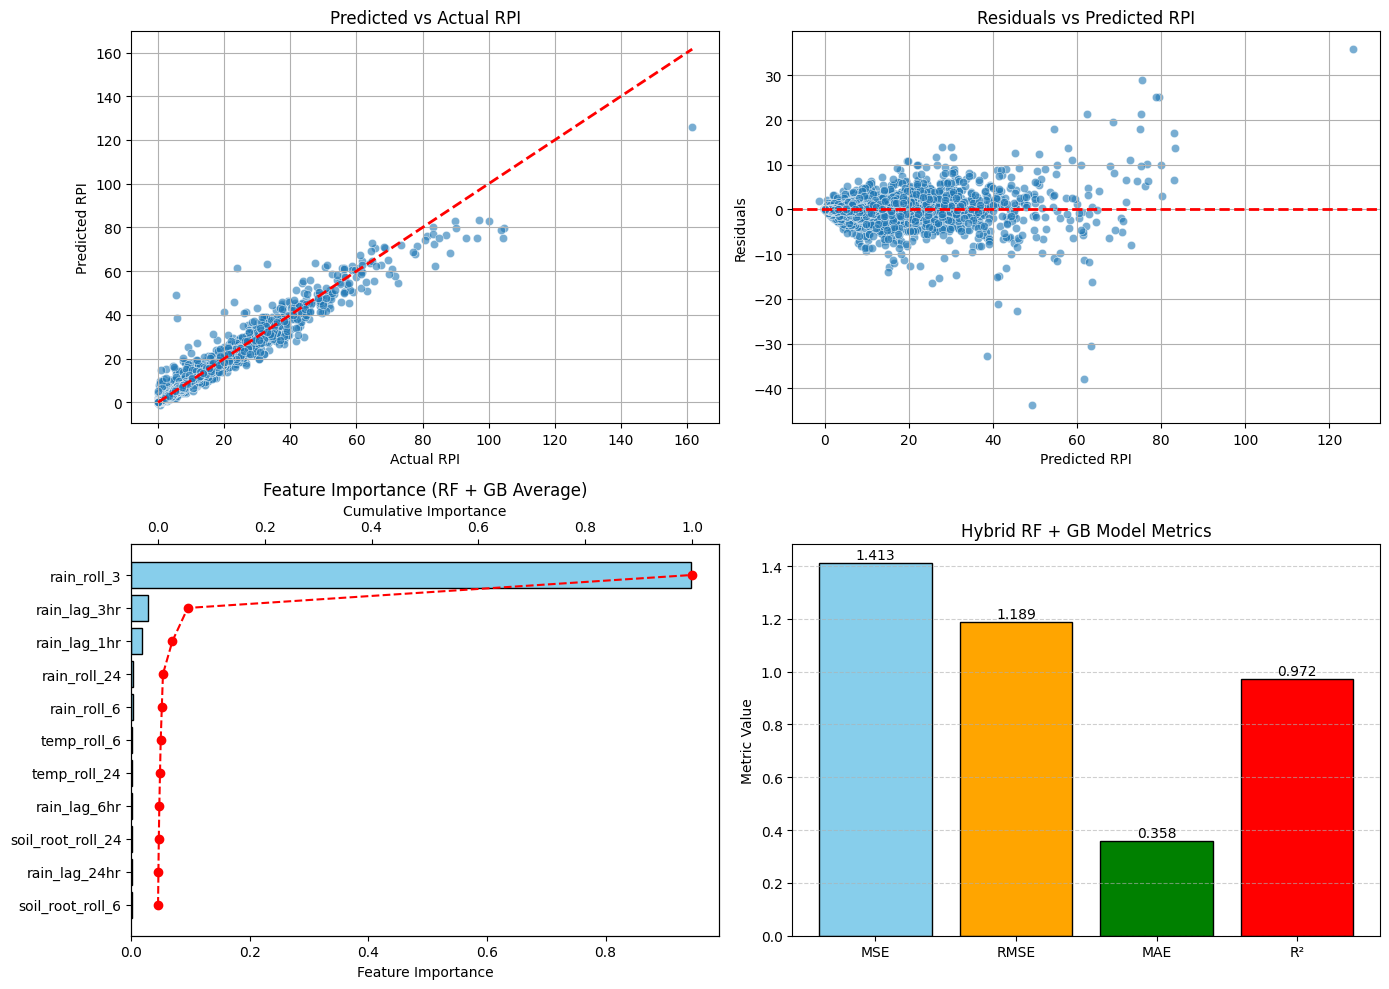

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ------------------------------
# Prepare data
# ------------------------------
residuals = y_test.values - y_pred_test

# Feature importance
rf_importances = rf_best.feature_importances_
gb_importances = gb_best.feature_importances_
feat_importances = (rf_importances + gb_importances) / 2

feat_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feat_importances
}).sort_values(by='Importance', ascending=True)  # ascending for horizontal bar
feat_df['Cumulative'] = feat_df['Importance'].cumsum()

# Metrics dictionary for bar chart
metrics_dict = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R²": r2}

# ------------------------------
# Create 4-panel figure
# ------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# ------------------------------
# 1️⃣ Predicted vs Actual
# ------------------------------
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6, ax=axs[0,0])
axs[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axs[0,0].set_xlabel("Actual RPI")
axs[0,0].set_ylabel("Predicted RPI")
axs[0,0].set_title("Predicted vs Actual RPI")
axs[0,0].grid(True)

# ------------------------------
# 2️⃣ Residuals vs Predicted
# ------------------------------
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.6, ax=axs[0,1])
axs[0,1].axhline(0, color='r', linestyle='--', linewidth=2)
axs[0,1].set_xlabel("Predicted RPI")
axs[0,1].set_ylabel("Residuals")
axs[0,1].set_title("Residuals vs Predicted RPI")
axs[0,1].grid(True)

# ------------------------------
# 3️⃣ Alternate Feature Importance
# ------------------------------
axs[1,0].barh(feat_df['Feature'], feat_df['Importance'], color='skyblue', edgecolor='k')
axs[1,0].set_xlabel("Feature Importance")
axs[1,0].set_title("Feature Importance (RF + GB Average)")

# Cumulative importance line
ax2 = axs[1,0].twiny()
ax2.plot(feat_df['Cumulative'], feat_df['Feature'], color='red', marker='o', linestyle='--')
ax2.set_xlabel("Cumulative Importance")

# ------------------------------
# 4️⃣ Metrics Bar Chart (Hybrid Model Performance)
# ------------------------------
metric_names = list(metrics_dict.keys())
metric_values = list(metrics_dict.values())

axs[1,1].bar(metric_names, metric_values, color=['skyblue','orange','green','red'], edgecolor='k')
axs[1,1].set_ylabel("Metric Value")
axs[1,1].set_title("Hybrid RF + GB Model Metrics")
for i, v in enumerate(metric_values):
    axs[1,1].text(i, v + 0.01*max(metric_values), f"{v:.3f}", ha='center', fontsize=10)
axs[1,1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **COMPARISION MODEL**

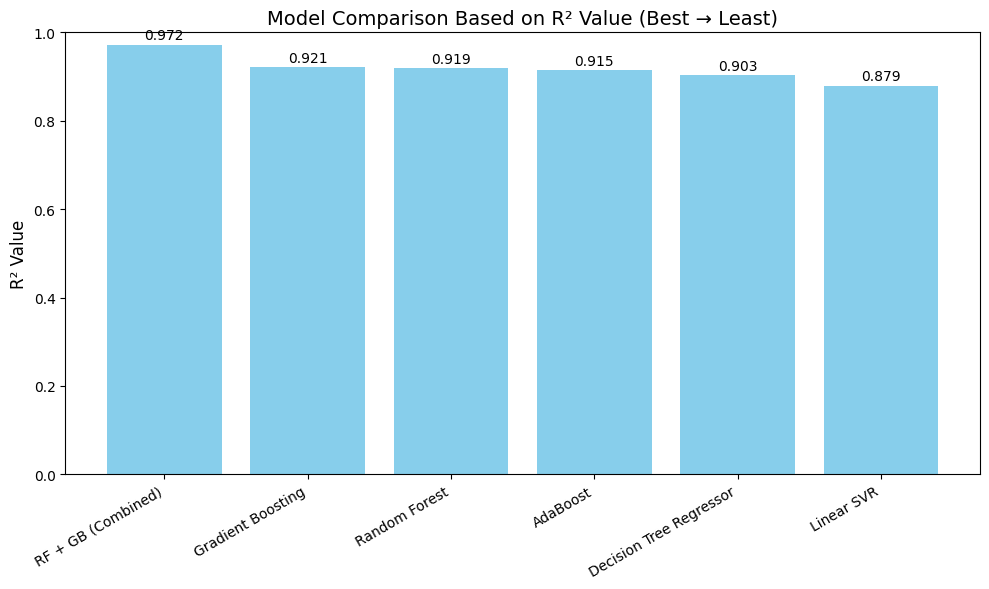

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = '/content/modei_camp.xlsx'  # replace with your file path
df = pd.read_excel(file_path)

# Sort by R² descending
df_sorted = df.sort_values(by='R²', ascending=False)

# Extract sorted model names and R² values
models = df_sorted['Model'].tolist()
r2_values = df_sorted['R²'].tolist()

# Create bar chart
plt.figure(figsize=(10,6))
bars = plt.bar(models, r2_values, color='skyblue')

# Add R² values on top of bars
for bar, r2 in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{r2:.3f}',
             ha='center', va='bottom', fontsize=10)

plt.title("Model Comparison Based on R² Value (Best → Least)", fontsize=14)
plt.ylabel("R² Value", fontsize=12)
plt.ylim(0, 1)  # R² ranges from 0 to 1
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()